# 2026-10-06 Emission-line fading, BPT ratios, and intrinsic H$\alpha$ dispersion

Focused extraction of source **cell 22 of 39** from
`20260909_check_corrected_Halpha_surface_density_SF_NSF_ND_by_stage.ipynb`.
The original notebook is unchanged. This notebook asks separately whether line
surface densities fade, whether BPT ratios change, and whether intrinsic
H$\alpha$ dispersion changes across pre-, close-, and post-peak stages,
in **NSF only**. This is a dated copy of
`20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb`;
the source notebook is unchanged. SF is retained internally only to define NSF
and check the category partition. TNSF is a proposed later refinement, not applied here.

Each plotting cell addresses one observable and category. It shows the
equal-galaxy figure first, followed by the pooled-spaxel sensitivity figure.
Both use whole-galaxy bootstrap 16--84% intervals (10,000 draws).
Stage differences compare different galaxies, not a longitudinal sequence.
Fading or ratio increases are questions to check, not assumptions imposed on the data.

The final section repeats every plot for
`NSF & finite(PROXY_EWHA) & (PROXY_EWHA < 3)`, using the same estimators.
No additional NII or SII class cut is applied to this NSF subset.


## Configuration
Run from the `further` directory. Input FITS products are read only; figures are embedded and are not saved separately.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
FIXED_RELIABLE_RANGES = {"log_sigma_star": (7.0, 9.5), "radius_re": (0.0, 2.5)}
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: emission-line intensities, BPT ratios and intrinsic Halpha sigma in NSF only")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
MIN_SUPPORT_GALAXIES = 3
MIN_SF_PIXELS_FOR_SUPPORT = MIN_SF_PIXELS_PER_BIN
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}
COMPONENT_COLORS = {
    "occupancy": "#2166ac",
    "survivor_intensity": "#e69f00",
    "total_hii": "#111111",
}


import warnings

COLOR_TABLE_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
CATEGORY_ORDER = ("NSF",)
# Preserve the source NSF bootstrap seed offset after dropping the SF branch.
CATEGORY_SEED_INDEX = {"NSF": 1}
MIN_CATEGORY_PIXELS_PER_BIN = 20
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
DIAGNOSTIC_ORDER = ("log_OIII_Hb", "log_NII_Ha", "log_SII_Ha", "log_OI_Ha", "sigma_Ha")
DIAGNOSTIC_LABELS = {
    "log_OIII_Hb": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$",
    "log_NII_Ha": r"$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$",
    "log_SII_Ha": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$",
    "log_OI_Ha": r"$\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$",
    "sigma_Ha": r"$\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$]",
}
BPT_LINE_ORDER = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII_SUM")
BPT_LINE_LABELS = {
    "HA6562": r"H$\alpha$",
    "OIII5006": r"[O III]$\lambda5007$",
    "NII6583": r"[N II]$\lambda6583$",
    "SII_SUM": r"[S II]$\lambda\lambda6716,6731$",
}

BPT_LINE_LABELS["HB4861"] = r"H$\beta$"

SOURCE_NOTEBOOK_SHA256 = 'b8d6b5776172abcf1273789d464b3baf93af7b6967435c20274ad9481ecf5a4e'

Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: emission-line intensities, BPT ratios and intrinsic Halpha sigma in NSF only
No additional inclination correction is applied to either surface-density map.


## 2. Exact shared masks and geometry

The inherited partition is

$$
\begin{aligned}
\mathrm{SF} &= \mathrm{valid}\cap\mathrm{finite}(\Sigma_{\rm SFR,HII})
\cap[\mathrm{EW}(\mathrm{H}\alpha)>6\,\AA]
\cap[\sigma_{\mathrm{H}\alpha,\rm intr}<45\,\mathrm{km\,s^{-1}}],\\
\mathrm{ND} &= \mathrm{valid}\cap\neg(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected}),\\
\mathrm{NSF} &= \mathrm{valid}\cap(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected})\cap\neg\mathrm{SF}.
\end{aligned}
$$

Detection means raw line `flux/error >= CUT_SN` and `flux >= NOISE`, with the
thresholds read from each gas FITS primary header. These observational
categories are mutually exclusive and exhaustive on the valid disc; NSF is not
a unique physical mechanism.


The strict retained footprint also requires finite `SNR_POSTFIT > 25`.
Intrinsic dispersion is $\sqrt{\sigma_{\rm obs}^2-\sigma_{\rm corr}^2}$;
non-positive radicands remain unavailable, rather than being set to zero.
The SF mask is used only to define the NSF complement; SF results are not plotted.
NSF includes multiple observational causes of failing the SF selection.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

## Proposed later refinement: TNSF (not applied)

`SFR+Z.py` writes independent class maps using dust-corrected BPT ratios:
`NII_BPT`: -1 = unknown/non-detection, 0 = unclassified, 1 = HII,
2 = composite, 3 = AGN branch. Positive codes require the central position
and the four axis offsets at +/-1 sigma to stay in the same class.
`SII_BPT`: 1 = HII, 2 = LINER, 3 = Seyfert, with the same stability rule.

The literal composite-exclusion refinement would be
`TNSF = NSF & (NII_BPT != 2)` on the existing valid, strict-S/N footprint.
It removes stable composites, but retains NII-HII pixels that failed an EW,
dispersion or SII gate, plus ambiguous (0) and unavailable (-1) NII classes.
Those retained classes do not provide a secure NII non-HII classification.

For a stricter, positively classified subset, the proposed definition is
`TNSF = NSF & (NII_BPT == 3)`. This excludes NII-HII, composite, ambiguous
and unavailable classes. It is an operational BPT selection; the name
"true NSF" does not establish zero SF contribution or a unique power source.
An additional SII non-HII requirement would be a separate, narrower choice.

Before applying the later cut, report NSF counts in every NII class (-1 to 3),
the retained fraction by galaxy and stage, and diagnostic support after the cut.
Keep the existing usable-disc denominator, common six-line support, and
finite-dispersion support distinct. This notebook currently uses NSF unchanged.


## Live sample and product QC
The source catalogue, inclination cut, combined-system geometry and WCS checks are retained. Excluded products and stage membership are shown explicitly.

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_NSF": int(maps["nsf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")

,GALID,components,stage,inclination_deg,N_valid,N_NSF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,44039,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,38973,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,263460,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,124396,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,28161,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,9195,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,34479,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,63907,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,53815,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,46546,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


## Corrected line maps and common support

Absolute profiles and BPT ratios use the **same six-line-detected pixels**:
H$\alpha$, H$\beta$, [O III], [N II], and both [S II] components, using each
product's `CUT_SN` and `NOISE`. Surface densities follow the source's
H$\alpha$ / `SFRCOEF` conversion and corrected line/H$\alpha$ scaling.
H$\beta$ is added explicitly so [O III]/H$\beta$ uses its actual denominator.

Dispersion uses all finite intrinsic-sigma pixels in each SF/NSF region,
without imposing the extra forbidden-line detection gate. These supports
answer different questions and must not be treated as identical populations.


In [4]:
def raw_line_detected(flux, error, cut_sn, noise):
    measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return measurable & (flux / error >= cut_sn) & (flux >= noise)

def safe_log_ratio(numerator, denominator, usable):
    result = np.full(np.asarray(numerator).shape, np.nan, dtype=float)
    good = usable & np.isfinite(numerator) & np.isfinite(denominator)
    good &= (numerator > 0) & (denominator > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        result[good] = np.log10(numerator[good] / denominator[good])
    return result

def bpt_line_surface_densities(log_lha_surface, corrected, common_valid):
    ha_corrected = np.asarray(corrected["HA6562"], dtype=float)
    line_fluxes = {
        "HA6562": ha_corrected,
        "HB4861": np.asarray(corrected["HB4861"], dtype=float),
        "OIII5006": np.asarray(corrected["OIII5006"], dtype=float),
        "NII6583": np.asarray(corrected["NII6583"], dtype=float),
        "SII_SUM": (
            np.asarray(corrected["SII6716"], dtype=float)
            + np.asarray(corrected["SII6730"], dtype=float)
        ),
    }
    result = {}
    for line, flux in line_fluxes.items():
        values = np.full(np.asarray(log_lha_surface).shape, np.nan, dtype=float)
        good = (
            np.asarray(common_valid, dtype=bool)
            & np.isfinite(log_lha_surface) & np.isfinite(ha_corrected)
            & np.isfinite(flux) & (ha_corrected > 0) & (flux > 0)
        )
        values[good] = (
            np.asarray(log_lha_surface)[good]
            + np.log10(flux[good] / ha_corrected[good])
        )
        result[line] = values
    return result

def load_halpha_category_maps(row, geometry):
    maps = load_galaxy_maps(row, geometry)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header.copy()
        cut_sn = float(header["CUT_SN"])
        noise = float(header["NOISE"])
        sfrcoef = float(header["SFRCOEF"])
        if not (np.isfinite(sfrcoef) and sfrcoef > 0):
            raise ValueError(f"{row.GALID}: invalid SFRCOEF={sfrcoef}")

        def arr(name):
            return np.asarray(hdul[name].data, dtype=float).copy()

        raw = {}
        raw_err = {}
        corrected = {}
        for line in ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730", "OI6300"):
            raw[line] = arr(line + "_FLUX")
            raw_err[line] = arr(line + "_FLUX_ERR")
            corrected[line] = arr(line + "_FLUX_CORR")
        log_sigma_sfr_all = arr("LOGSFR_SURFACE_DENSITY")
        sigma_obs = arr(HALPHA_SIGMA_OBS_HDU)
        sigma_corr = arr(HALPHA_SIGMA_CORR_HDU)
        ew_ha = load_fits_map(row.ew_path, EW_HDU)

        provenance = {
            key: header.get(key, "not recorded")
            for key in (
                "CUT_SN", "NOISE", "DIST_MPC", "DISTREF", "SFRCOEF",
                "SFRIMF", "DUSTLAW", "BPTMODE", "SFRNOTE",
            )
        }

    shapes = {value.shape for value in [
        *raw.values(), *raw_err.values(), *corrected.values(),
        log_sigma_sfr_all, sigma_obs, sigma_corr, ew_ha,
    ]}
    if shapes != {maps["valid_disc_mask"].shape}:
        raise ValueError(f"{row.GALID}: added-map shape mismatch {sorted(shapes)}")

    detected = {
        line: raw_line_detected(raw[line], raw_err[line], cut_sn, noise)
        for line in raw
    }
    if not np.array_equal(detected["HA6562"], maps["line_detected"]["HA6562"]):
        raise AssertionError(f"{row.GALID}: inherited Halpha detection mismatch")
    if not np.array_equal(detected["HB4861"], maps["line_detected"]["HB4861"]):
        raise AssertionError(f"{row.GALID}: inherited Hbeta detection mismatch")

    balmer = detected["HA6562"] & detected["HB4861"]
    oiii_ok = detected["OIII5006"] & detected["HB4861"]
    nii_ok = balmer & detected["NII6583"]
    sii_ok = balmer & detected["SII6716"] & detected["SII6730"]
    oi_ok = balmer & detected["OI6300"]
    bpt_common_valid = (
        detected["HA6562"] & detected["HB4861"]
        & detected["OIII5006"] & detected["NII6583"]
        & detected["SII6716"] & detected["SII6730"]
    )
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    log_lha_surface = log_sigma_sfr_all - np.log10(sfrcoef)
    log_bpt_line_surface = bpt_line_surface_densities(
        log_lha_surface, corrected, bpt_common_valid
    )

    maps.update({
        "log_lha_surface": log_lha_surface,
        "ew_ha": ew_ha,
        "sigma_intrinsic": sigma_intrinsic,
        "bpt_common_valid": bpt_common_valid,
        "log_bpt_line_surface": log_bpt_line_surface,
        "diagnostics": {
            "log_OIII_Hb": safe_log_ratio(
                corrected["OIII5006"], corrected["HB4861"], oiii_ok
            ),
            "log_NII_Ha": safe_log_ratio(
                corrected["NII6583"], corrected["HA6562"], nii_ok
            ),
            "log_SII_Ha": safe_log_ratio(
                corrected["SII6716"] + corrected["SII6730"],
                corrected["HA6562"], sii_ok,
            ),
            "log_OI_Ha": safe_log_ratio(
                corrected["OI6300"], corrected["HA6562"], oi_ok
            ),
            "sigma_Ha": sigma_intrinsic,
        },
        "diagnostic_valid": {
            "log_OIII_Hb": oiii_ok,
            "log_NII_Ha": nii_ok,
            "log_SII_Ha": sii_ok,
            "log_OI_Ha": oi_ok,
            "sigma_Ha": np.isfinite(sigma_intrinsic),
        },
        "halpha_provenance": provenance,
        "sfrcoef": sfrcoef,
    })
    measured = maps["sf_mask"] | maps["nsf_mask"]
    if np.any(measured & ~balmer):
        raise AssertionError(f"{row.GALID}: SF/NSF includes a Balmer non-detection")
    if np.any(measured & ~np.isfinite(log_lha_surface)):
        raise AssertionError(f"{row.GALID}: measured category lacks corrected Halpha")
    return maps

## Measurements and estimators

Bins have width 0.25 in $\log_{10}\Sigma_\star$ or $R/R_e$.
A galaxy/bin needs at least 50 usable pixels and 20 relevant diagnostic pixels.
Plots retain the source's fixed ranges: $7\leq\log_{10}\Sigma_\star<9.5$
and $0\leq R/R_e<2.5$. These ranges alone do not guarantee enough galaxies.
Support counts are reported below; a one-galaxy bootstrap can collapse to zero width.

Line intensity: linear mean within each galaxy/category, then equal-galaxy mean.
BPT ratio: ratio of those stage mean intensities (not mean spaxel log-ratio).
The pooled alternative is a ratio of total line luminosities on the same support.
Dispersion: mean intrinsic sigma within each galaxy/category, then equal-galaxy
mean; the pooled alternative is the mean over supported pixels.
These sigma means differ from the source's median-based NSF-minus-SF
diagnostic and can be sensitive to broad fitted tails. No extra sigma-fit
quality cut is imposed; inspect those tails before physical interpretation.
Bootstrap ratios retain paired numerator/denominator galaxy draws.


In [5]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}
MASK_KEYS = {"SF": "sf_mask", "NSF": "nsf_mask", "ND": "nd_mask"}

measurement_rows = []
snr_rows = []
provenance_rows = []
all_retained_strict = True
for galaxy_row in sample.itertuples(index=False):
    maps = load_halpha_category_maps(galaxy_row, geometry)
    original_valid = maps["valid_disc_mask"]
    snr_postfit = maps["snr_postfit"]
    keep = original_valid & np.isfinite(snr_postfit) & (snr_postfit > SFH_SNR_POSTFIT_MIN)
    all_retained_strict &= bool(np.all(snr_postfit[keep] > SFH_SNR_POSTFIT_MIN))
    category_masks = {label: maps[key] & keep for label, key in MASK_KEYS.items()}
    category_total = sum(mask.astype(np.int8) for mask in category_masks.values())
    if not np.array_equal(category_total, keep.astype(np.int8)):
        raise AssertionError(f"{galaxy_row.GALID}: strict-cut category accounting failed")

    snr_rows.append({
        "GALID": galaxy_row.GALID,
        "stage": galaxy_row.stage,
        "N_valid_original": int(original_valid.sum()),
        "N_usable": int(keep.sum()),
        **{f"N_{label}": int(mask.sum()) for label, mask in category_masks.items()},
    })
    provenance_rows.append({"GALID": galaxy_row.GALID, **maps["halpha_provenance"]})

    for variable, edges in COMMON_EDGES.items():
        values = maps[variable]
        for lo, hi in zip(edges[:-1], edges[1:]):
            in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
            usable = keep & in_bin
            n_usable = int(usable.sum())
            eligible_usable = n_usable >= MIN_VALID_PIXELS_PER_BIN
            for category in CATEGORY_ORDER:
                category_mask = category_masks[category] & in_bin
                n_category = int(category_mask.sum())
                linear_lha = np.power(10.0, maps["log_lha_surface"][category_mask])
                if linear_lha.size and (
                    not np.isfinite(linear_lha).all() or np.any(linear_lha <= 0)
                ):
                    raise AssertionError(
                        f"{galaxy_row.GALID} {category}: invalid Halpha surface density"
                    )
                sum_lha = float(linear_lha.sum())
                category_support = bool(
                    eligible_usable and n_category >= MIN_CATEGORY_PIXELS_PER_BIN
                )
                record = {
                    "GALID": galaxy_row.GALID,
                    "stage": galaxy_row.stage,
                    "variable": variable,
                    "bin_left": float(lo),
                    "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "category": category,
                    "N_usable": n_usable,
                    "N_category": n_category,
                    "eligible_usable": bool(eligible_usable),
                    "category_support": category_support,
                    "f_category": n_category / n_usable if eligible_usable else np.nan,
                    "sum_lha_within_category": sum_lha,
                    "lha_mean_within_category": (
                        sum_lha / n_category if n_category > 0 else np.nan
                    ),
                    "median_log_lha_within_category": (
                        float(np.nanmedian(maps["log_lha_surface"][category_mask]))
                        if n_category > 0 else np.nan
                    ),
                    "log_lha_values_within_category": np.asarray(
                        maps["log_lha_surface"][category_mask], dtype=np.float32
                    ),
                }
                bpt_common_mask = (
                    category_mask & maps["bpt_common_valid"]
                    if category in CATEGORY_ORDER
                    else np.zeros(category_mask.shape, dtype=bool)
                )
                n_bpt_common = int(bpt_common_mask.sum())
                record["N_bpt_common"] = n_bpt_common
                record["bpt_common_support"] = bool(
                    eligible_usable
                    and n_bpt_common >= DIAGNOSTIC_MIN_PIXELS_PER_BIN
                )
                for line in BPT_LINE_ORDER:
                    linear_line = np.power(
                        10.0, maps["log_bpt_line_surface"][line][bpt_common_mask]
                    )
                    if linear_line.size and (
                        not np.isfinite(linear_line).all() or np.any(linear_line <= 0)
                    ):
                        raise AssertionError(
                            f"{galaxy_row.GALID} {category} {line}: "
                            "invalid BPT-line surface density"
                        )
                    record[f"sum_{line}_within_category"] = float(linear_line.sum())
                    record[f"mean_{line}_within_category"] = (
                        float(linear_line.mean()) if linear_line.size else np.nan
                    )
                for diagnostic in DIAGNOSTIC_ORDER:
                    diagnostic_mask = (
                        category_mask & maps["diagnostic_valid"][diagnostic]
                        & np.isfinite(maps["diagnostics"][diagnostic])
                    )
                    # ND lacks a valid Balmer-decrement correction and is not
                    # used in corrected excitation-ratio comparisons.
                    if category == "ND":
                        diagnostic_mask &= False
                    n_diagnostic = int(diagnostic_mask.sum())
                    record[f"N_{diagnostic}"] = n_diagnostic
                    diagnostic_values = np.asarray(
                        maps["diagnostics"][diagnostic][diagnostic_mask],
                        dtype=np.float32,
                    )
                    record[f"values_{diagnostic}"] = diagnostic_values
                    record[f"median_{diagnostic}"] = (
                        float(np.nanmedian(diagnostic_values))
                        if n_diagnostic > 0 else np.nan
                    )
                measurement_rows.append(record)
    del maps

HALPHA_BY_GALAXY_BIN = pd.DataFrame(measurement_rows)
SNR_SUMMARY = pd.DataFrame(snr_rows)
HALPHA_PROVENANCE = pd.DataFrame(provenance_rows)
STAGE_TOTAL_GALAXIES = {
    stage: int(sample.loc[sample.stage.eq(stage), "GALID"].nunique())
    for stage in STAGE_ORDER
}

assert all_retained_strict
assert set(HALPHA_BY_GALAXY_BIN.GALID) == set(sample.GALID)
assert set(HALPHA_BY_GALAXY_BIN.category) == {"NSF"}
assert (HALPHA_BY_GALAXY_BIN.N_category <= HALPHA_BY_GALAXY_BIN.N_usable).all()
print("Strict-S/N retained sample by stage")
display(SNR_SUMMARY.groupby("stage").agg(
    N_galaxies=("GALID", "nunique"),
    N_usable=("N_usable", "sum"),
    N_NSF=("N_NSF", "sum"),
).reindex(STAGE_ORDER))

Strict-S/N retained sample by stage


,N_galaxies,N_usable,N_NSF
stage,,,
pre-peak,8,2703316,929104
close-to-peak,5,1643790,488865
post-peak,13,2825159,815887


In [6]:
def finite_percentiles(values):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    return tuple(np.percentile(finite, [16, 84])) if finite.size else (np.nan, np.nan)

def stage_bpt_line_estimator(per_galaxy, *, category_order=CATEGORY_ORDER):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    selected = per_galaxy.loc[per_galaxy.category.isin(category_order)]
    for group_keys, group in selected.groupby(keys, observed=True, sort=False):
        base = dict(zip(keys, group_keys))
        supported = group.loc[group.bpt_common_support]
        lo, hi = FIXED_RELIABLE_RANGES[base["variable"]]
        for line in BPT_LINE_ORDER:
            rec = dict(base)
            rec["line"] = line
            rec["N_gal_support"] = int(supported.GALID.nunique())
            rec["mean_line_surface"] = (
                float(supported[f"mean_{line}_within_category"].mean())
                if len(supported) else np.nan
            )
            rec["in_fixed_reliable_range"] = bool(
                rec["center"] >= lo and rec["center"] < hi
            )
            rows.append(rec)
    return pd.DataFrame(rows)

def bootstrap_bpt_line_profiles(per_galaxy, n_boot=N_BOOTSTRAP, *, category_order=CATEGORY_ORDER, profiles=None):
    profiles = BPT_LINE_PROFILES if profiles is None else profiles
    rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[
            sample.stage.eq(stage), "GALID"
        ].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category in category_order:
                category_index = CATEGORY_SEED_INDEX[category]
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                # Use shared galaxy-resampling indices across BPT lines so
                # BPT-ratio changes retain their within-galaxy pairing.
                for line in BPT_LINE_ORDER:
                    for bin_index, (lo, hi) in enumerate(zip(
                        COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                    )):
                        group = stage_frame.loc[
                            np.isclose(stage_frame.bin_left, lo)
                        ].set_index("GALID").reindex(stage_galaxies)
                        supported = group.bpt_common_support.fillna(False).to_numpy(bool)
                        values = np.where(
                            supported,
                            group[f"mean_{line}_within_category"].to_numpy(float),
                            np.nan,
                        )
                        seed = (
                            RANDOM_SEED + 13_000_000 + 1_000_000 * stage_index
                            + 100_000 * variable_index + 10_000 * category_index
                            + bin_index
                        )
                        rng = np.random.default_rng(seed)
                        indices = rng.integers(
                            0, len(stage_galaxies),
                            size=(n_boot, len(stage_galaxies)),
                        )
                        sampled = values[indices]
                        counts = np.isfinite(sampled).sum(axis=1)
                        draws = np.divide(
                            np.nansum(sampled, axis=1), counts,
                            out=np.full(n_boot, np.nan), where=counts > 0,
                        )
                        key = (stage, variable, category, line, float(lo))
                        draws_by_key[key] = draws
                        central = profiles.loc[
                            profiles.stage.eq(stage)
                            & profiles.variable.eq(variable)
                            & profiles.category.eq(category)
                            & profiles.line.eq(line)
                            & np.isclose(profiles.bin_left, lo)
                        ].iloc[0]
                        value_lo, value_hi = finite_percentiles(draws)
                        rows.append({
                            "stage": stage, "variable": variable,
                            "category": category, "line": line,
                            "bin_left": float(lo), "bin_right": float(hi),
                            "center": float((lo + hi) / 2),
                            "N_gal_support": int(central.N_gal_support),
                            "in_fixed_reliable_range": bool(
                                central.in_fixed_reliable_range
                            ),
                            "mean_line_surface": float(central.mean_line_surface),
                            "mean_line_surface_lo": value_lo,
                            "mean_line_surface_hi": value_hi,
                        })
    return pd.DataFrame(rows), draws_by_key

def pooled_bpt_line_estimator(per_galaxy, *, category_order=CATEGORY_ORDER):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    selected = per_galaxy.loc[per_galaxy.category.isin(category_order)]
    for group_keys, group in selected.groupby(keys, observed=True, sort=False):
        base = dict(zip(keys, group_keys))
        supported = group.loc[group.bpt_common_support]
        n_pixels = int(supported.N_bpt_common.sum())
        lo, hi = FIXED_RELIABLE_RANGES[base["variable"]]
        for line in BPT_LINE_ORDER:
            rec = dict(base)
            rec["line"] = line
            rec["N_gal_support"] = int(supported.GALID.nunique())
            rec["N_spaxel_support"] = n_pixels
            line_sum = float(supported[f"sum_{line}_within_category"].sum())
            rec["mean_line_surface"] = (
                line_sum / n_pixels if n_pixels > 0 else np.nan
            )
            rec["in_fixed_reliable_range"] = bool(
                rec["center"] >= lo and rec["center"] < hi
            )
            rows.append(rec)
    return pd.DataFrame(rows)

def bootstrap_pooled_bpt_line_profiles(per_galaxy, n_boot=N_BOOTSTRAP, *, category_order=CATEGORY_ORDER, profiles=None):
    profiles = POOLED_BPT_LINE_PROFILES if profiles is None else profiles
    rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[
            sample.stage.eq(stage), "GALID"
        ].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category in category_order:
                category_index = CATEGORY_SEED_INDEX[category]
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                for line in BPT_LINE_ORDER:
                    for bin_index, (lo, hi) in enumerate(zip(
                        COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                    )):
                        group = stage_frame.loc[
                            np.isclose(stage_frame.bin_left, lo)
                        ].set_index("GALID").reindex(stage_galaxies)
                        supported = group.bpt_common_support.fillna(False).to_numpy(bool)
                        n_pixels = np.where(
                            supported,
                            group.N_bpt_common.fillna(0).to_numpy(float),
                            0.0,
                        )
                        line_sum = np.where(
                            supported,
                            group[f"sum_{line}_within_category"].fillna(0).to_numpy(float),
                            0.0,
                        )
                        seed = (
                            RANDOM_SEED + 14_000_000 + 1_000_000 * stage_index
                            + 100_000 * variable_index + 10_000 * category_index
                            + bin_index
                        )
                        rng = np.random.default_rng(seed)
                        indices = rng.integers(
                            0, len(stage_galaxies),
                            size=(n_boot, len(stage_galaxies)),
                        )
                        pixel_boot = n_pixels[indices].sum(axis=1)
                        line_boot = line_sum[indices].sum(axis=1)
                        draws = np.divide(
                            line_boot, pixel_boot,
                            out=np.full(n_boot, np.nan), where=pixel_boot > 0,
                        )
                        key = (stage, variable, category, line, float(lo))
                        draws_by_key[key] = draws
                        central = profiles.loc[
                            profiles.stage.eq(stage)
                            & profiles.variable.eq(variable)
                            & profiles.category.eq(category)
                            & profiles.line.eq(line)
                            & np.isclose(profiles.bin_left, lo)
                        ].iloc[0]
                        value_lo, value_hi = finite_percentiles(draws)
                        rows.append({
                            "stage": stage, "variable": variable,
                            "category": category, "line": line,
                            "bin_left": float(lo), "bin_right": float(hi),
                            "center": float((lo + hi) / 2),
                            "N_gal_support": int(central.N_gal_support),
                            "N_spaxel_support": int(central.N_spaxel_support),
                            "in_fixed_reliable_range": bool(
                                central.in_fixed_reliable_range
                            ),
                            "mean_line_surface": float(central.mean_line_surface),
                            "mean_line_surface_lo": value_lo,
                            "mean_line_surface_hi": value_hi,
                        })
    return pd.DataFrame(rows), draws_by_key

BPT_LINE_PROFILES = stage_bpt_line_estimator(HALPHA_BY_GALAXY_BIN)
BPT_LINE_BOOTSTRAP, BPT_LINE_BOOTSTRAP_DRAWS = bootstrap_bpt_line_profiles(HALPHA_BY_GALAXY_BIN)
POOLED_BPT_LINE_PROFILES = pooled_bpt_line_estimator(HALPHA_BY_GALAXY_BIN)
POOLED_BPT_LINE_BOOTSTRAP, POOLED_BPT_LINE_BOOTSTRAP_DRAWS = bootstrap_pooled_bpt_line_profiles(HALPHA_BY_GALAXY_BIN)

In [7]:
RATIO_DENOMINATORS = {"OIII5006": "HB4861", "NII6583": "HA6562", "SII_SUM": "HA6562"}
RATIO_LABELS = {
    "OIII5006": r"$\log_{10}([\mathrm{O\,III}]/\mathrm{H}\beta)$",
    "NII6583": r"$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$",
    "SII_SUM": r"$\log_{10}([\mathrm{S\,II}]/\mathrm{H}\alpha)$",
}
VARIABLES = ("log_sigma_star", "radius_re")
BRANCH_LABELS = {"equal": "Equal-galaxy", "pooled": "Pooled-spaxel"}
LINE_TABLES = {"equal": BPT_LINE_BOOTSTRAP, "pooled": POOLED_BPT_LINE_BOOTSTRAP}
LINE_DRAWS = {"equal": BPT_LINE_BOOTSTRAP_DRAWS, "pooled": POOLED_BPT_LINE_BOOTSTRAP_DRAWS}

def log_positive(value):
    value = np.asarray(value, dtype=float)
    result = np.full(value.shape, np.nan)
    good = np.isfinite(value) & (value > 0)
    result[good] = np.log10(value[good])
    return result

def build_ratio_profiles(table, draws):
    indexed = table.set_index(["stage", "variable", "category", "line", "bin_left"])
    rows, ratio_draws = [], {}
    for item in table.loc[table.line.isin(RATIO_DENOMINATORS)].itertuples(index=False):
        key = (item.stage, item.variable, item.category, item.line, float(item.bin_left))
        den_key = (item.stage, item.variable, item.category, RATIO_DENOMINATORS[item.line], float(item.bin_left))
        denominator = indexed.loc[den_key]
        boot = log_positive(draws[key]) - log_positive(draws[den_key])
        ratio_draws[key] = boot
        lo, hi = finite_percentiles(boot)
        rows.append({**item._asdict(),
                     "value": float(log_positive(item.mean_line_surface) - log_positive(denominator.mean_line_surface)),
                     "value_lo": lo, "value_hi": hi})
    return pd.DataFrame(rows), ratio_draws

RATIO_TABLES, RATIO_DRAWS = {}, {}
for branch in BRANCH_LABELS:
    RATIO_TABLES[branch], RATIO_DRAWS[branch] = build_ratio_profiles(LINE_TABLES[branch], LINE_DRAWS[branch])

def stage_contrasts(table, draws, value_column, *, logarithmic=False):
    indexed = table.set_index(["stage", "variable", "category", "line", "bin_left"])
    rows = []
    for item in table.loc[table.stage.ne("pre-peak")].itertuples(index=False):
        key = (item.stage, item.variable, item.category, item.line, float(item.bin_left))
        pre_key = ("pre-peak", *key[1:])
        pre = indexed.loc[pre_key]
        transform = log_positive if logarithmic else np.asarray
        boot = transform(draws[key]) - transform(draws[pre_key])
        lo, hi = finite_percentiles(boot)
        rows.append({**item._asdict(),
            "value": float(transform(getattr(item, value_column)) - transform(pre[value_column])),
            "value_lo": lo, "value_hi": hi,
            "N_gal_pre": int(pre.N_gal_support),
            "N_finite_draws": int(np.isfinite(boot).sum())})
    return pd.DataFrame(rows)

LINE_CONTRASTS = {b: stage_contrasts(LINE_TABLES[b], LINE_DRAWS[b], "mean_line_surface", logarithmic=True) for b in BRANCH_LABELS}
RATIO_CONTRASTS = {b: stage_contrasts(RATIO_TABLES[b], RATIO_DRAWS[b], "value") for b in BRANCH_LABELS}

In [8]:
def bootstrap_sigma_profiles(per_galaxy, n_boot=N_BOOTSTRAP, *, category_order=CATEGORY_ORDER):
    rows = {b: [] for b in BRANCH_LABELS}
    all_draws = {b: {} for b in BRANCH_LABELS}
    for si, stage in enumerate(STAGE_ORDER):
        galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
        # One complete-galaxy draw shared across every bin and category.
        indices = np.random.default_rng(RANDOM_SEED + 15000000 + si).integers(
            0, len(galaxies), size=(n_boot, len(galaxies)))
        for variable in VARIABLES:
            for category in category_order:
                selected = per_galaxy.loc[per_galaxy.stage.eq(stage) & per_galaxy.variable.eq(variable) & per_galaxy.category.eq(category)]
                for lo, hi in zip(COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]):
                    group = selected.loc[np.isclose(selected.bin_left, lo)].set_index("GALID").reindex(galaxies)
                    supported = group.eligible_usable.fillna(False).to_numpy(bool) & (group.N_sigma_Ha.fillna(0).to_numpy(float) >= DIAGNOSTIC_MIN_PIXELS_PER_BIN)
                    arrays = [np.asarray(v, dtype=float) if ok else np.array([]) for v, ok in zip(group.values_sigma_Ha, supported)]
                    counts = np.array([len(v) for v in arrays], dtype=float)
                    sums = np.array([v.sum() for v in arrays], dtype=float)
                    means = np.divide(sums, counts, out=np.full(len(galaxies), np.nan), where=counts > 0)
                    for branch in BRANCH_LABELS:
                        if branch == "equal":
                            selected_means = means[indices]
                            n = np.isfinite(selected_means).sum(axis=1)
                            boot = np.divide(np.nansum(selected_means, axis=1), n, out=np.full(n_boot, np.nan), where=n > 0)
                            central = float(means[np.isfinite(means)].mean()) if np.isfinite(means).any() else np.nan
                        else:
                            n = counts[indices].sum(axis=1)
                            boot = np.divide(sums[indices].sum(axis=1), n, out=np.full(n_boot, np.nan), where=n > 0)
                            central = float(sums.sum() / counts.sum()) if counts.sum() else np.nan
                        key = (stage, variable, category, "sigma_Ha", float(lo))
                        all_draws[branch][key] = boot
                        lower, upper = finite_percentiles(boot)
                        xmin, xmax = FIXED_RELIABLE_RANGES[variable]
                        rows[branch].append({"stage": stage, "variable": variable, "category": category,
                            "line": "sigma_Ha", "bin_left": float(lo), "bin_right": float(hi), "center": (lo+hi)/2,
                            "N_gal_support": int(supported.sum()), "N_spaxel_support": int(counts.sum()),
                            "in_fixed_reliable_range": xmin <= (lo+hi)/2 < xmax,
                            "value": central, "value_lo": lower, "value_hi": upper})
    return {b: pd.DataFrame(rows[b]) for b in rows}, all_draws

SIGMA_TABLES, SIGMA_DRAWS = bootstrap_sigma_profiles(HALPHA_BY_GALAXY_BIN)
SIGMA_CONTRASTS = {b: stage_contrasts(SIGMA_TABLES[b], SIGMA_DRAWS[b], "value") for b in BRANCH_LABELS}

SUPPORT_TABLE = pd.concat([
    BPT_LINE_BOOTSTRAP.loc[BPT_LINE_BOOTSTRAP.line.eq("HA6562")].assign(observable="Common BPT lines"),
    SIGMA_TABLES["equal"].assign(observable="Intrinsic Halpha sigma")
], ignore_index=True)
display(SUPPORT_TABLE.loc[SUPPORT_TABLE.in_fixed_reliable_range,
    ["observable", "category", "stage", "variable", "center", "N_gal_support"]])

,observable,category,stage,variable,center,N_gal_support
5,Common BPT lines,NSF,pre-peak,log_sigma_star,7.125,4
6,Common BPT lines,NSF,pre-peak,log_sigma_star,7.375,7
7,Common BPT lines,NSF,pre-peak,log_sigma_star,7.625,8
8,Common BPT lines,NSF,pre-peak,log_sigma_star,7.875,8
9,Common BPT lines,NSF,pre-peak,log_sigma_star,8.125,8
...,...,...,...,...,...,...
297,Intrinsic Halpha sigma,NSF,post-peak,radius_re,1.375,12
298,Intrinsic Halpha sigma,NSF,post-peak,radius_re,1.625,8
299,Intrinsic Halpha sigma,NSF,post-peak,radius_re,1.875,6
300,Intrinsic Halpha sigma,NSF,post-peak,radius_re,2.125,4


In [9]:
def plot_profiles(table, category, lines, labels, ylabel, title, *, contrast=False, log_intensity=False):
    fig, axes = plt.subplots(len(lines), 2, figsize=(12, max(4, 2.8 * len(lines))), squeeze=False, sharex="col")
    for ri, line in enumerate(lines):
        for ci, variable in enumerate(VARIABLES):
            ax = axes[ri, ci]
            for stage in (STAGE_ORDER[1:] if contrast else STAGE_ORDER):
                sub = table.loc[table.category.eq(category) & table.line.eq(line) & table.variable.eq(variable) & table.stage.eq(stage)].sort_values("center")
                shown = sub.in_fixed_reliable_range.to_numpy(bool)
                if log_intensity:
                    y, yl, yh = (log_positive(sub[k].to_numpy(float)) for k in ("mean_line_surface", "mean_line_surface_lo", "mean_line_surface_hi"))
                else:
                    y, yl, yh = (sub[k].to_numpy(float) for k in ("value", "value_lo", "value_hi"))
                x = sub.center.to_numpy(float)
                label = STAGE_LABELS[stage] + (" minus pre-peak" if contrast else "")
                ax.plot(x, np.where(shown, y, np.nan), color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8, label=label)
                ax.fill_between(x, np.where(shown, yl, np.nan), np.where(shown, yh, np.nan), color=STAGE_COLORS[stage], alpha=.15, linewidth=0)
            ax.set_xlim(*FIXED_RELIABLE_RANGES[variable])
            ax.set_title(labels[line])
            ax.set_xlabel(VARIABLE_LABELS[variable])
            ax.set_ylabel(ylabel)
            if contrast: ax.axhline(0, color=".5", ls="--", lw=1)
            ax.grid(alpha=.2)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(title + " - " + category, y=1.01)
    fig.tight_layout()
    plt.show()

def show_lines(category, contrast=False, *, tables=None, contrasts=None):
    tables = LINE_TABLES if tables is None else tables
    contrasts = LINE_CONTRASTS if contrasts is None else contrasts
    for branch in BRANCH_LABELS:
        plot_profiles(contrasts[branch] if contrast else tables[branch], category,
            BPT_LINE_ORDER, BPT_LINE_LABELS,
            r"$\Delta\log_{10} I_\ell$ [dex]" if contrast else r"$\log_{10} I_\ell$ [erg s$^{-1}$ kpc$^{-2}$]",
            BRANCH_LABELS[branch] + (" line change relative to pre-peak" if contrast else " absolute line surface density"),
            contrast=contrast, log_intensity=not contrast)

def show_ratios(category, contrast=False, *, tables=None, contrasts=None):
    tables = RATIO_TABLES if tables is None else tables
    contrasts = RATIO_CONTRASTS if contrasts is None else contrasts
    for branch in BRANCH_LABELS:
        plot_profiles(contrasts[branch] if contrast else tables[branch], category,
            tuple(RATIO_DENOMINATORS), RATIO_LABELS,
            r"$\Delta\log_{10}$ ratio [dex]" if contrast else r"$\log_{10}$ ratio",
            BRANCH_LABELS[branch] + (" BPT-ratio change relative to pre-peak" if contrast else " BPT ratios"), contrast=contrast)

def show_sigma(contrast=False, *, category_order=CATEGORY_ORDER, tables=None, contrasts=None):
    tables = SIGMA_TABLES if tables is None else tables
    contrasts = SIGMA_CONTRASTS if contrasts is None else contrasts
    for branch in BRANCH_LABELS:
        table = contrasts[branch] if contrast else tables[branch]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), squeeze=False, sharex="col", sharey="row")
        for ri, category in enumerate(category_order):
            for ci, variable in enumerate(VARIABLES):
                ax = axes[ri, ci]
                for stage in (STAGE_ORDER[1:] if contrast else STAGE_ORDER):
                    sub = table.loc[table.category.eq(category) & table.variable.eq(variable) & table.stage.eq(stage)].sort_values("center")
                    shown = sub.in_fixed_reliable_range.to_numpy(bool)
                    x = sub.center.to_numpy(float)
                    y, yl, yh = (np.where(shown, sub[k].to_numpy(float), np.nan) for k in ("value", "value_lo", "value_hi"))
                    ax.plot(x, y, color=STAGE_COLORS[stage], marker="o", ms=3, label=STAGE_LABELS[stage] + (" minus pre-peak" if contrast else ""))
                    ax.fill_between(x, yl, yh, color=STAGE_COLORS[stage], alpha=.15, linewidth=0)
                ax.set_xlim(*FIXED_RELIABLE_RANGES[variable])
                ax.set_title(category)
                ax.set_xlabel(VARIABLE_LABELS[variable])
                ax.set_ylabel((r"$\Delta\langle\sigma_{\rm intr}\rangle$" if contrast else r"$\langle\sigma_{\rm intr}\rangle$") + r" [km s$^{-1}$]")
                if contrast: ax.axhline(0, color=".5", ls="--", lw=1)
                ax.grid(alpha=.2)
        axes[0, 0].legend(frameon=False, fontsize=9)
        fig.suptitle(BRANCH_LABELS[branch] + " intrinsic Halpha dispersion" + (" change relative to pre-peak" if contrast else ""), y=1.01)
        fig.tight_layout()
        plt.show()

## Absolute line surface densities: NSF
The five lines use matched common BPT-valid support, including Hbeta explicitly.

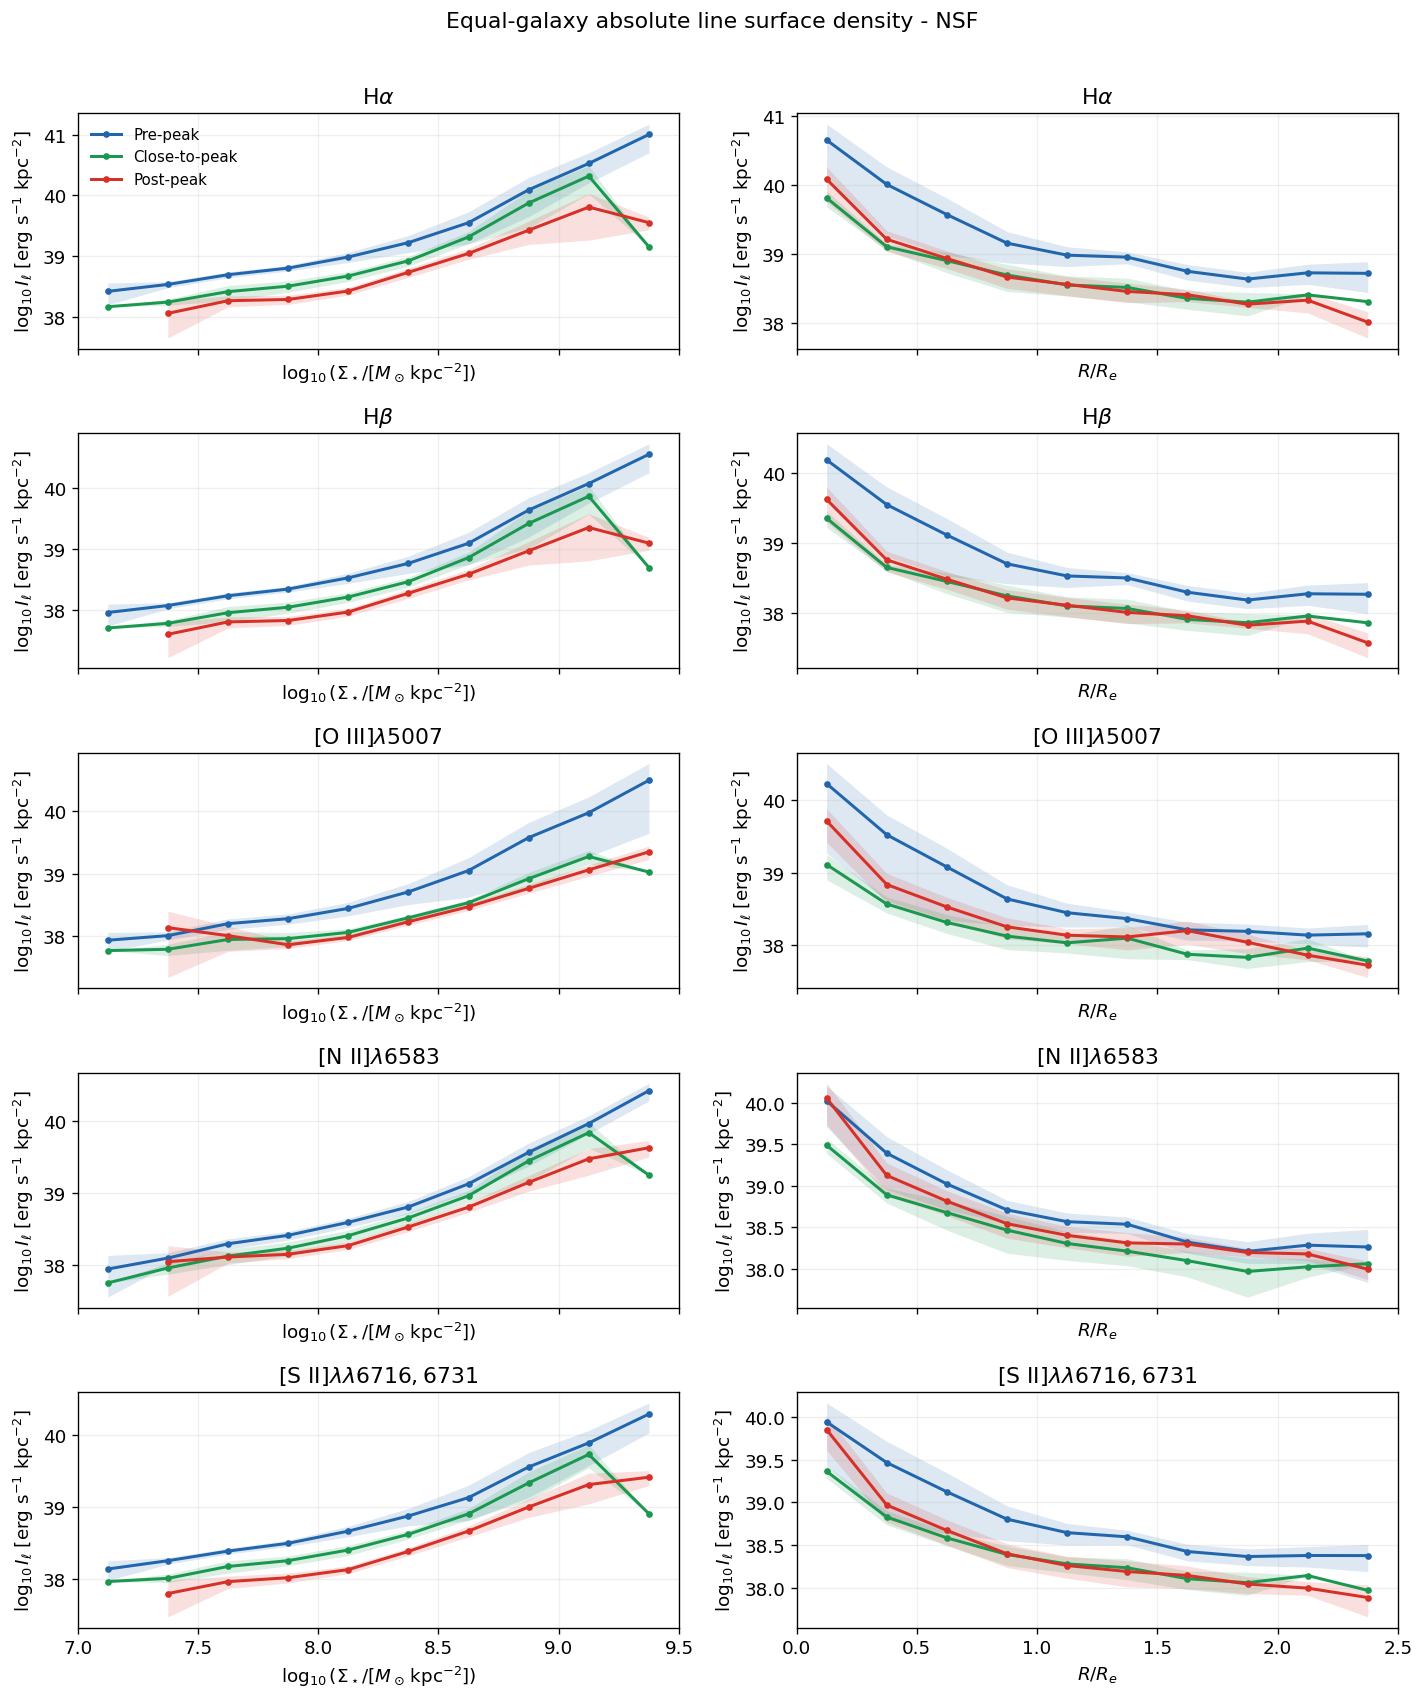

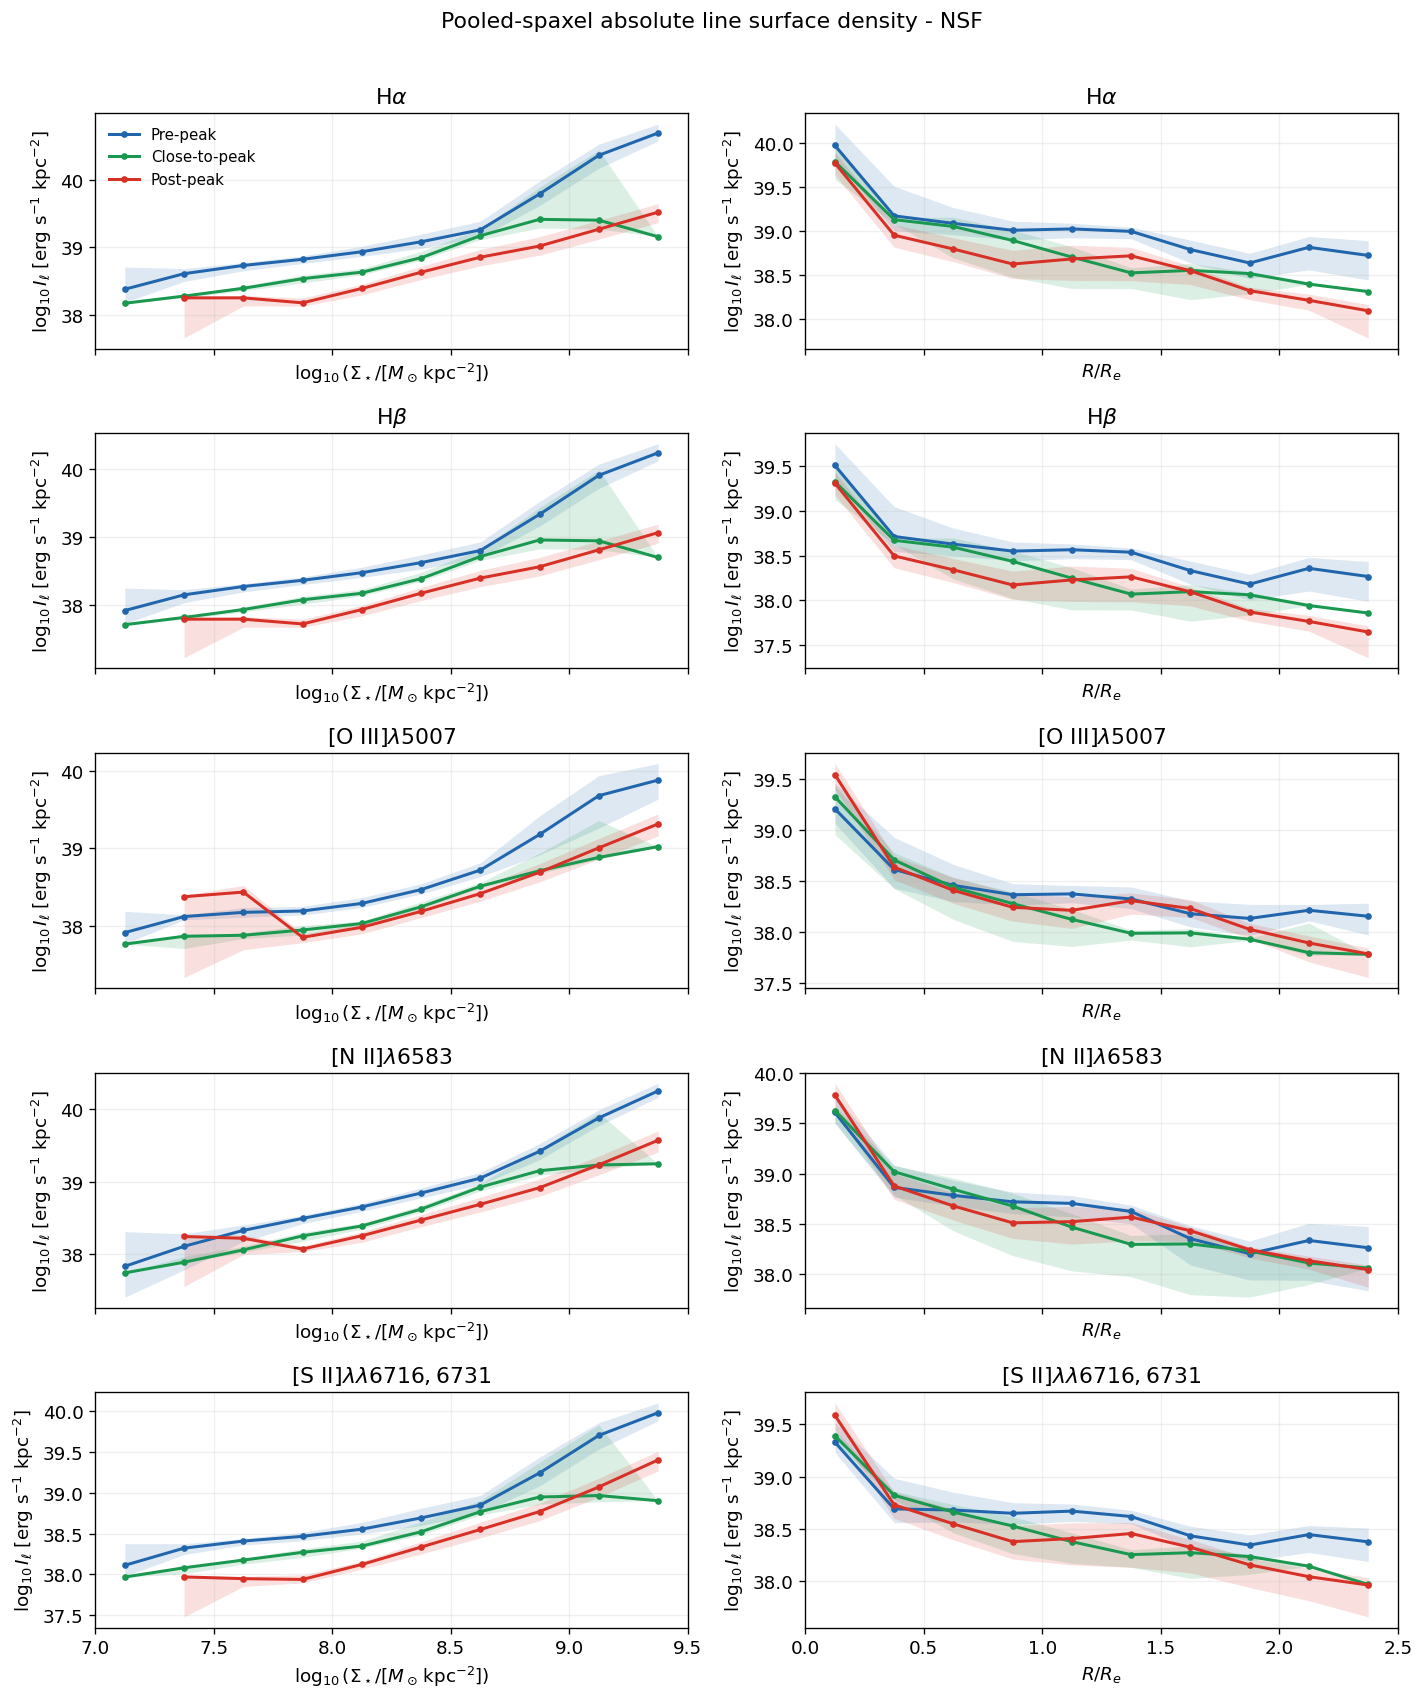

In [10]:
show_lines("NSF")

## Absolute line changes relative to pre-peak: NSF
Negative values indicate fainter emission on matched support. Close-minus-pre and post-minus-pre do not by themselves establish a monotonic sequence.

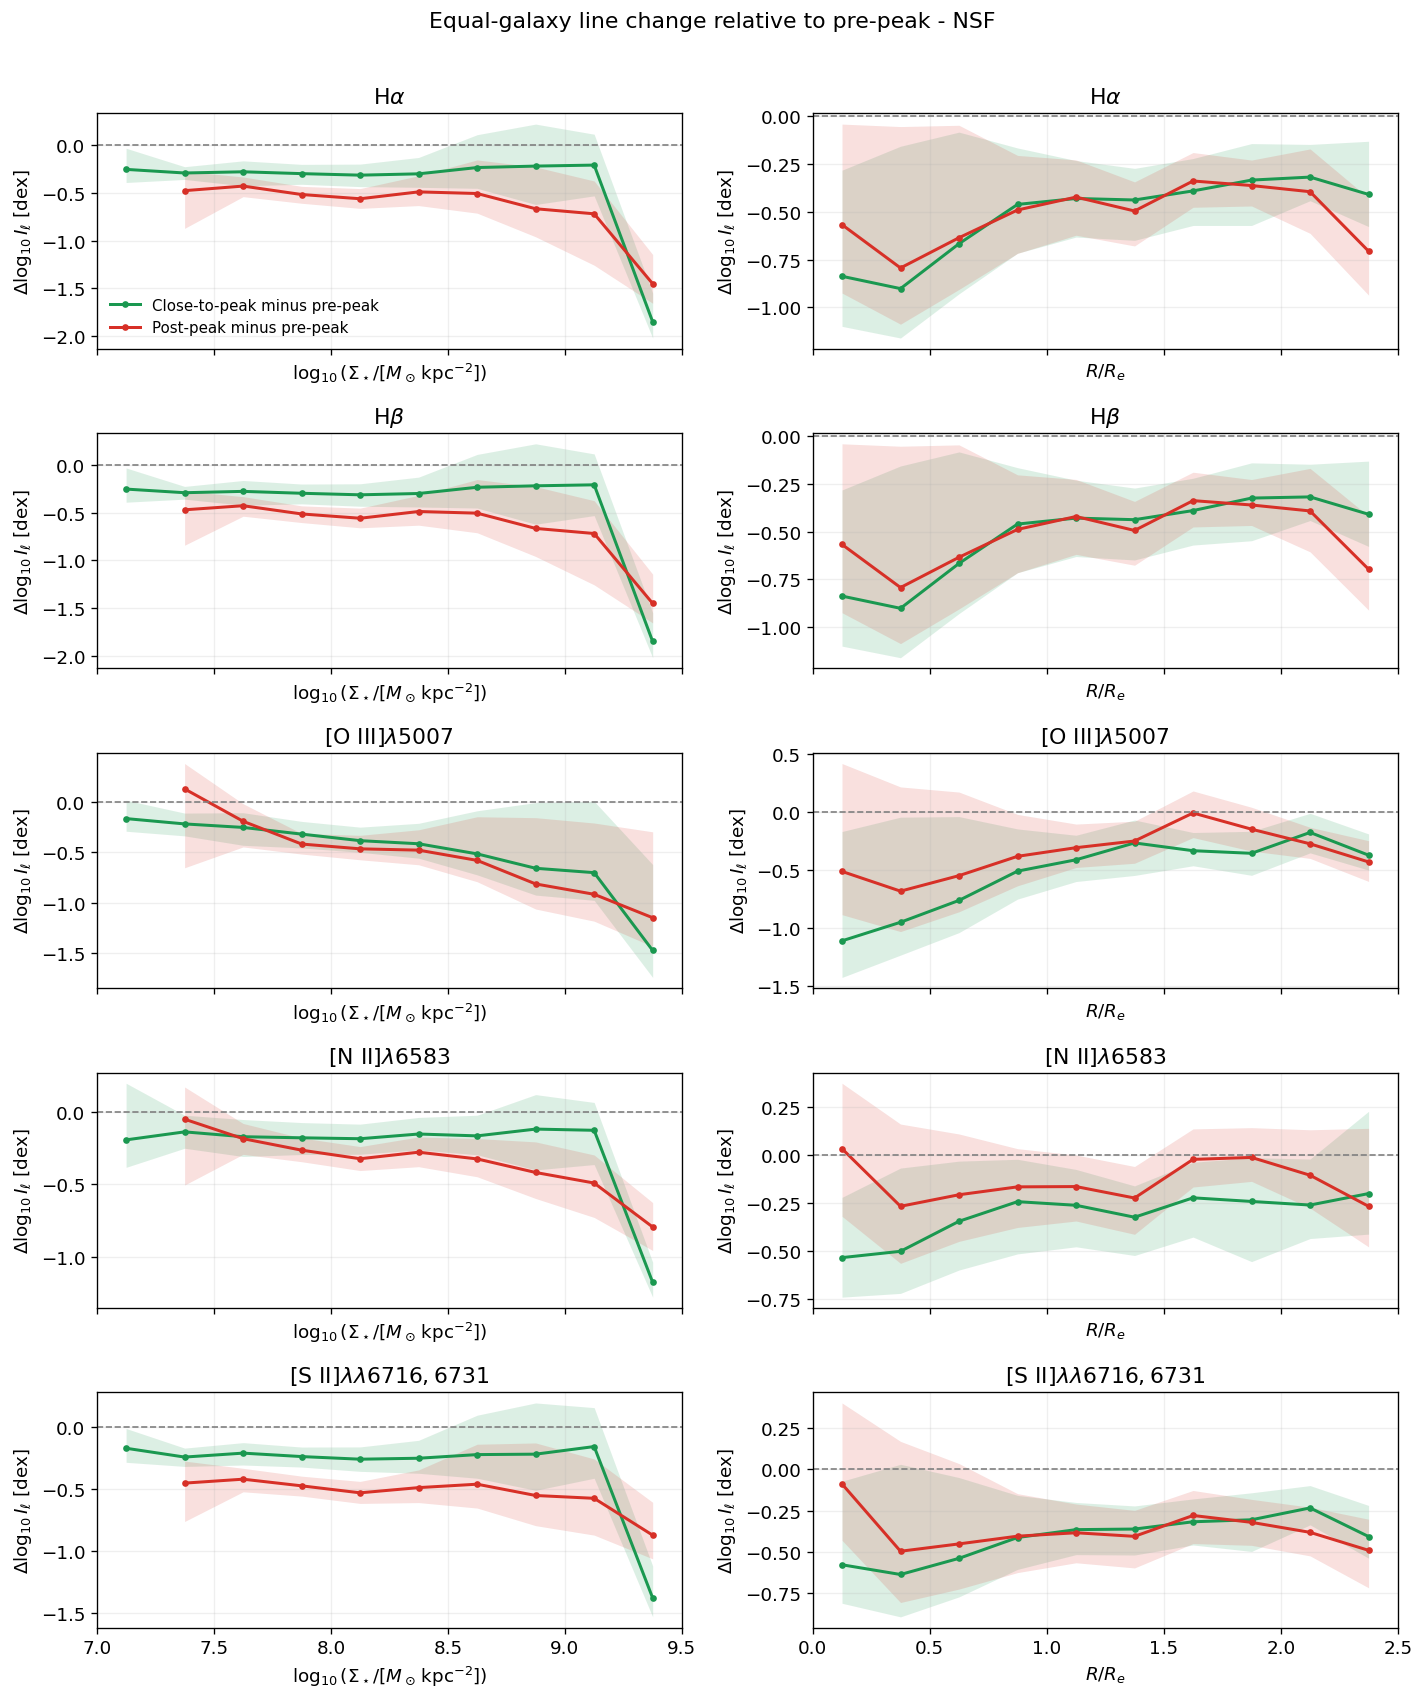

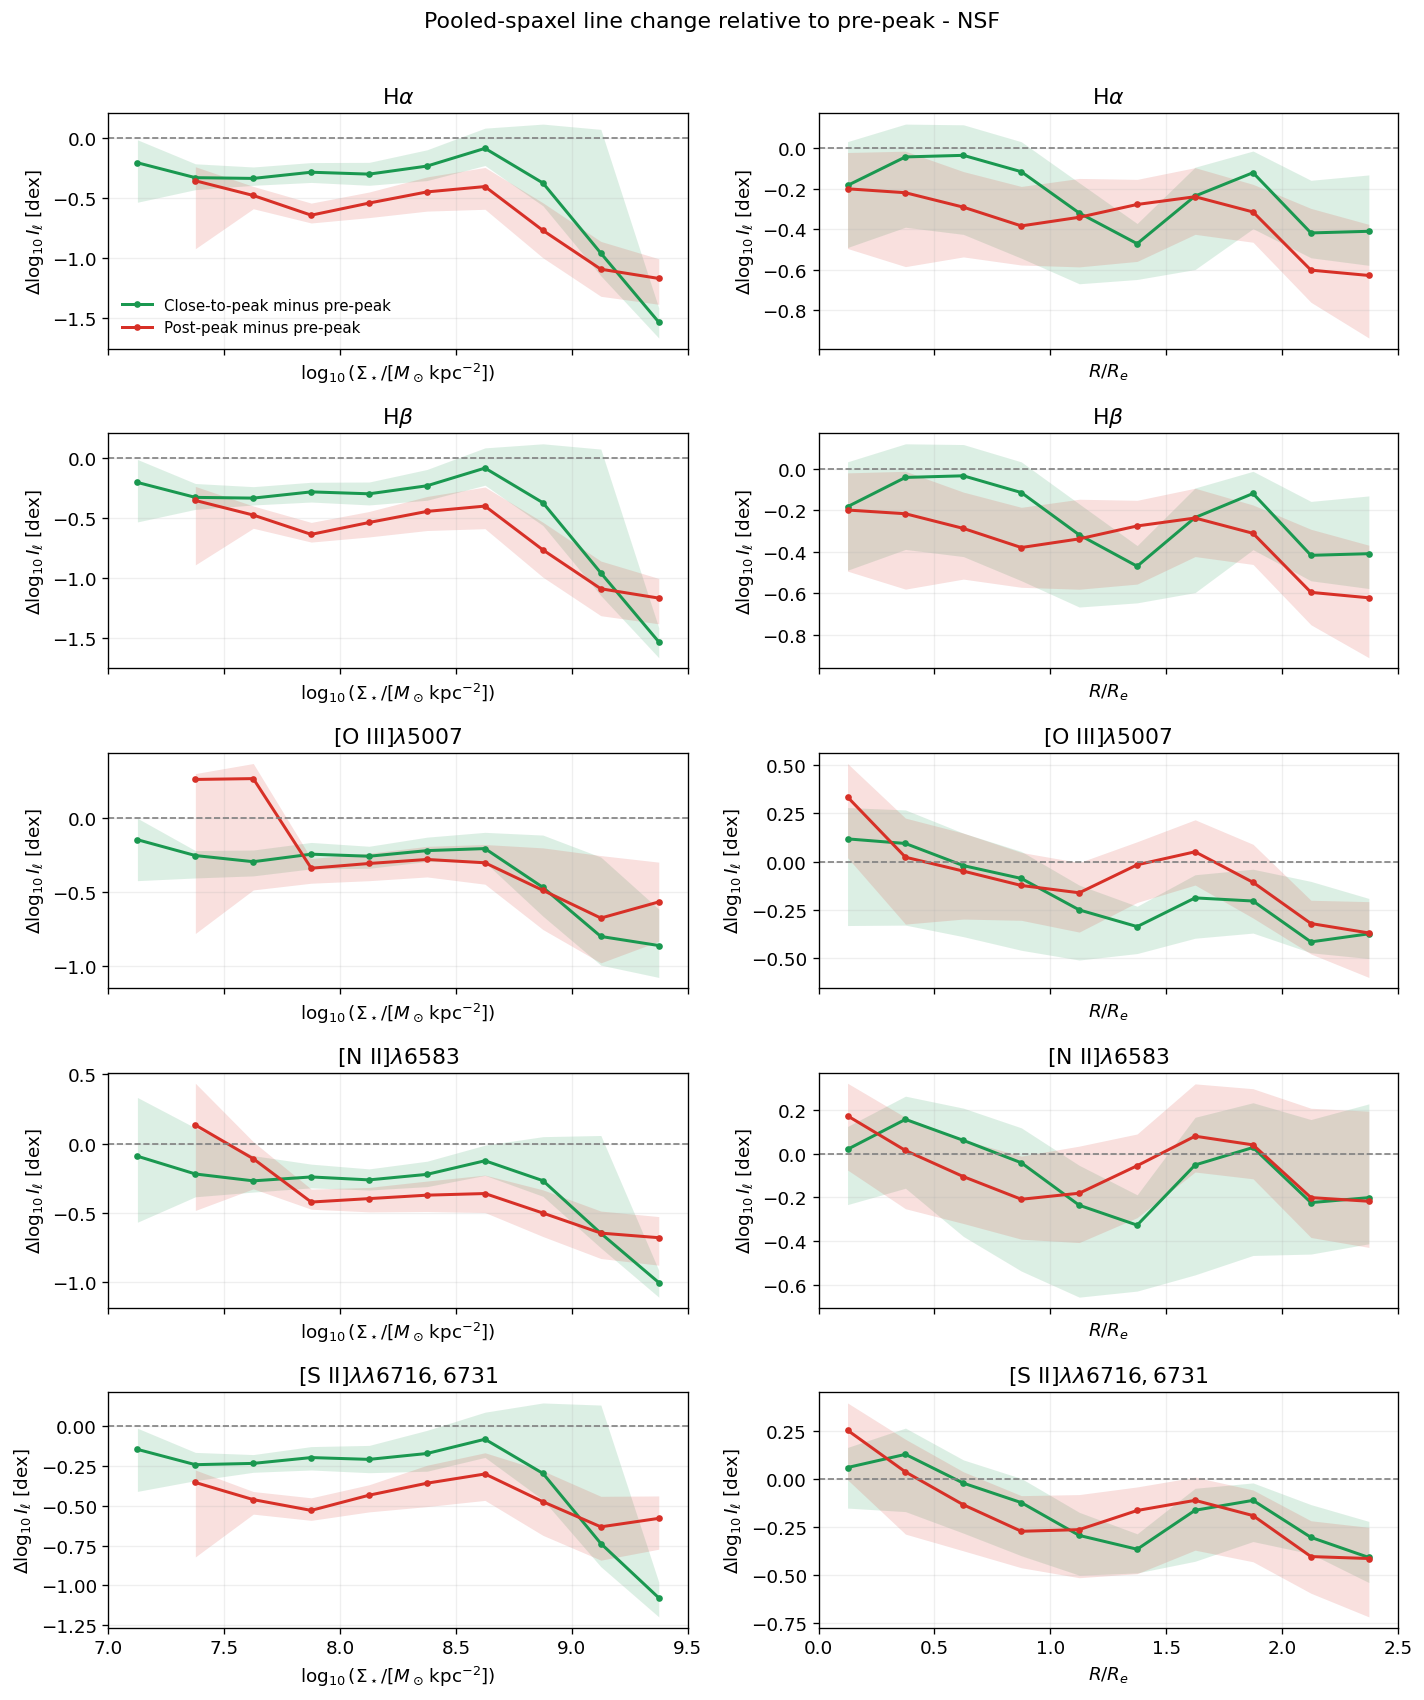

In [11]:
show_lines("NSF", contrast=True)

## BPT-ratio profiles: NSF
Ratios of stage mean corrected intensities on common support; [O III] uses Hbeta.

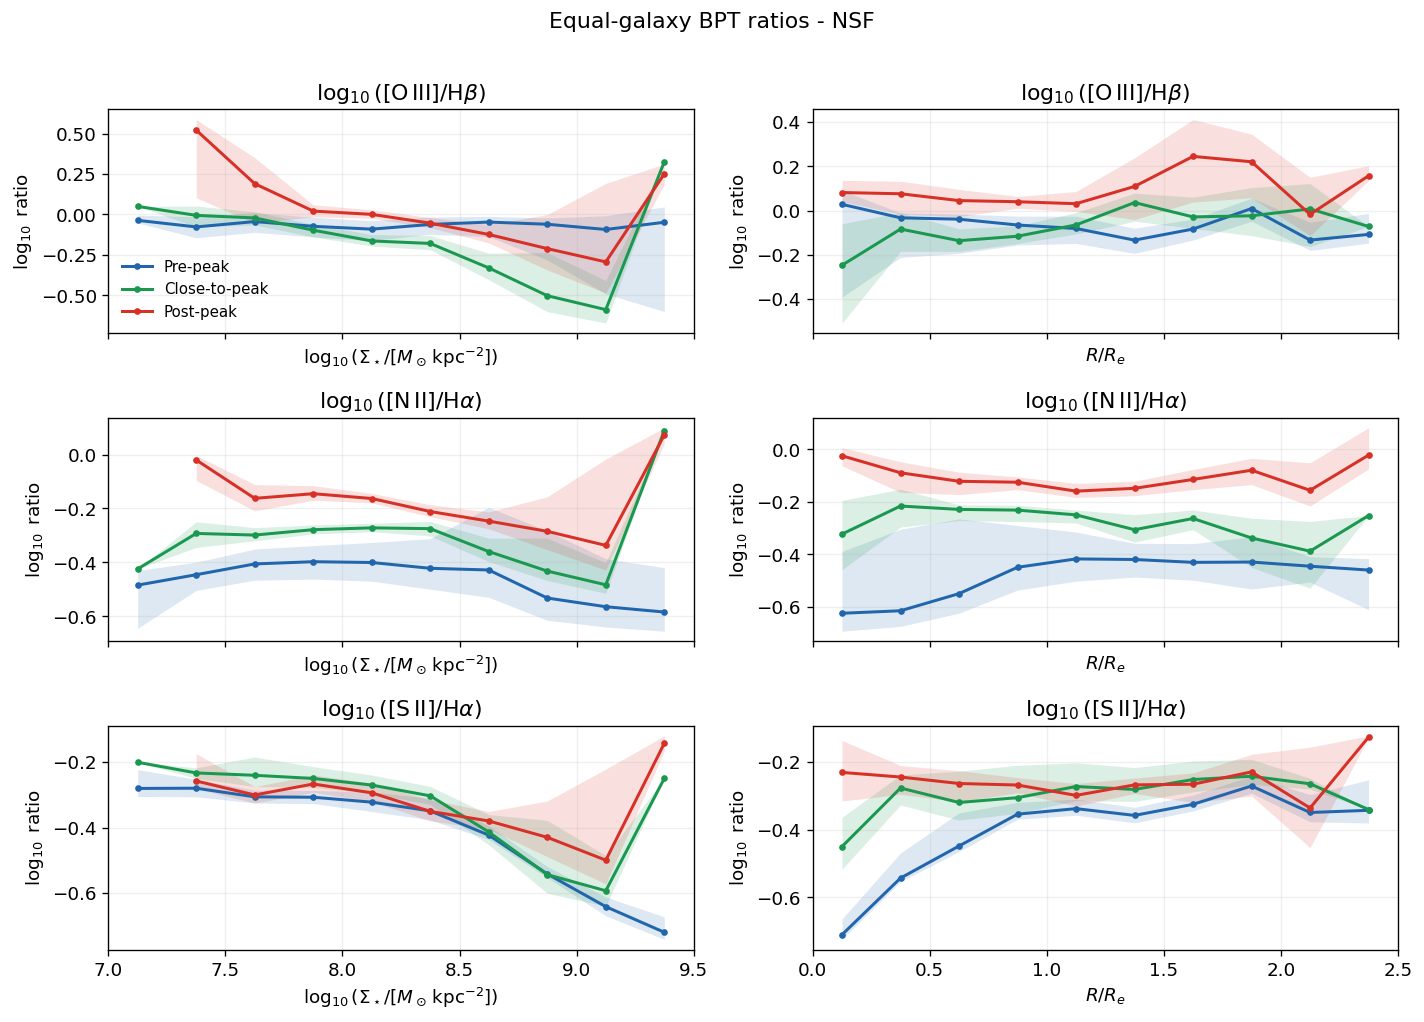

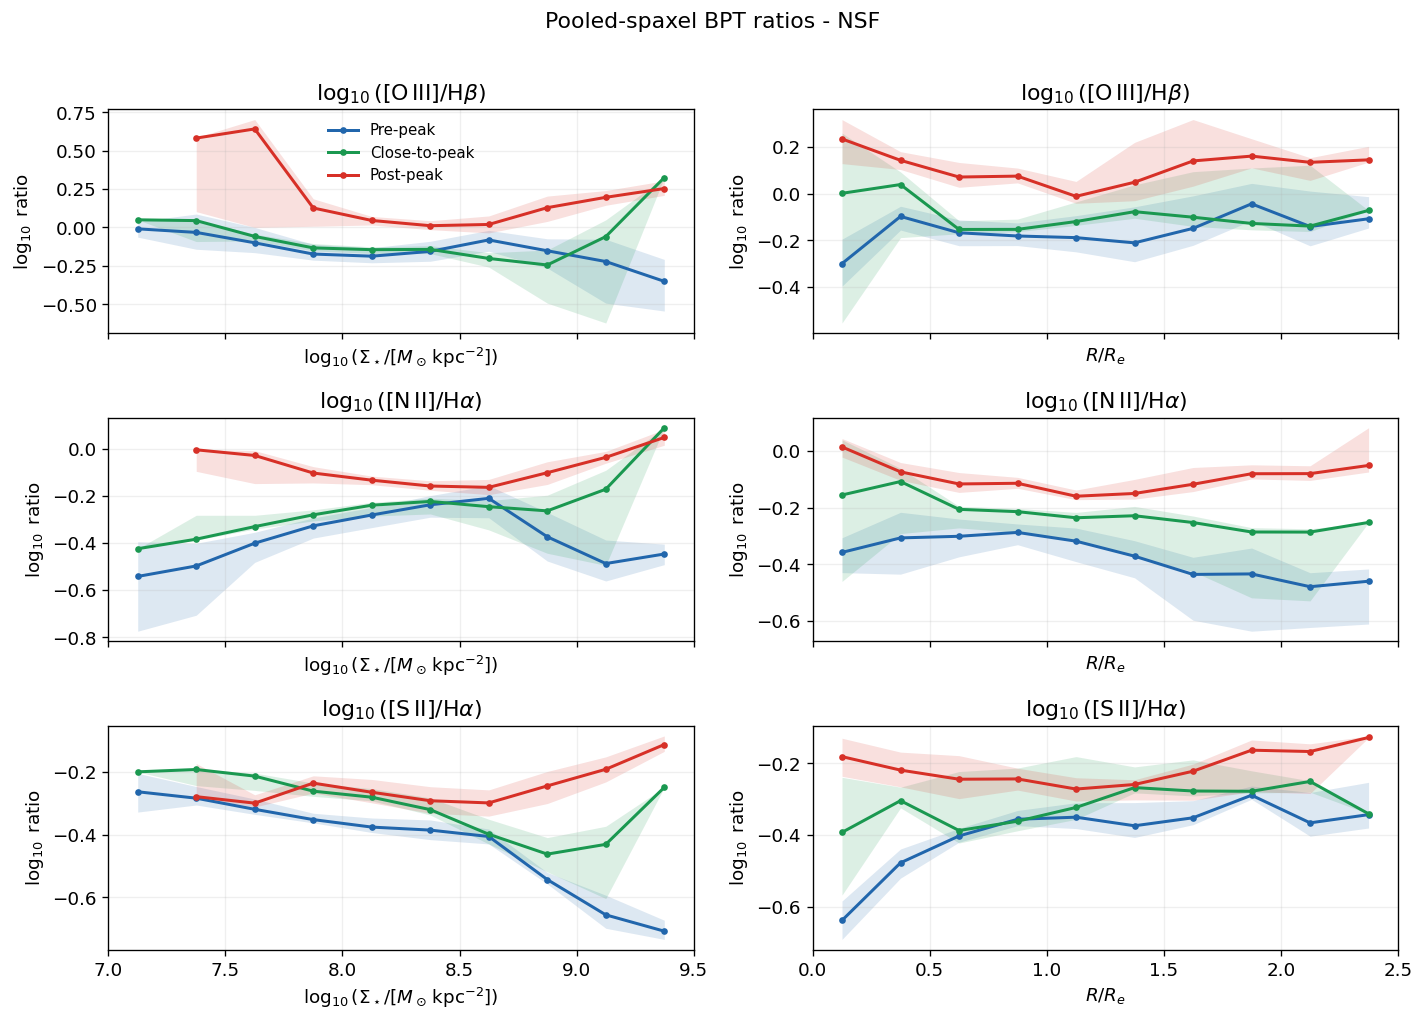

In [12]:
show_ratios("NSF")

## BPT-ratio changes relative to pre-peak: NSF
Positive values indicate larger ratios. A larger ratio can accompany fading of both numerator and denominator.

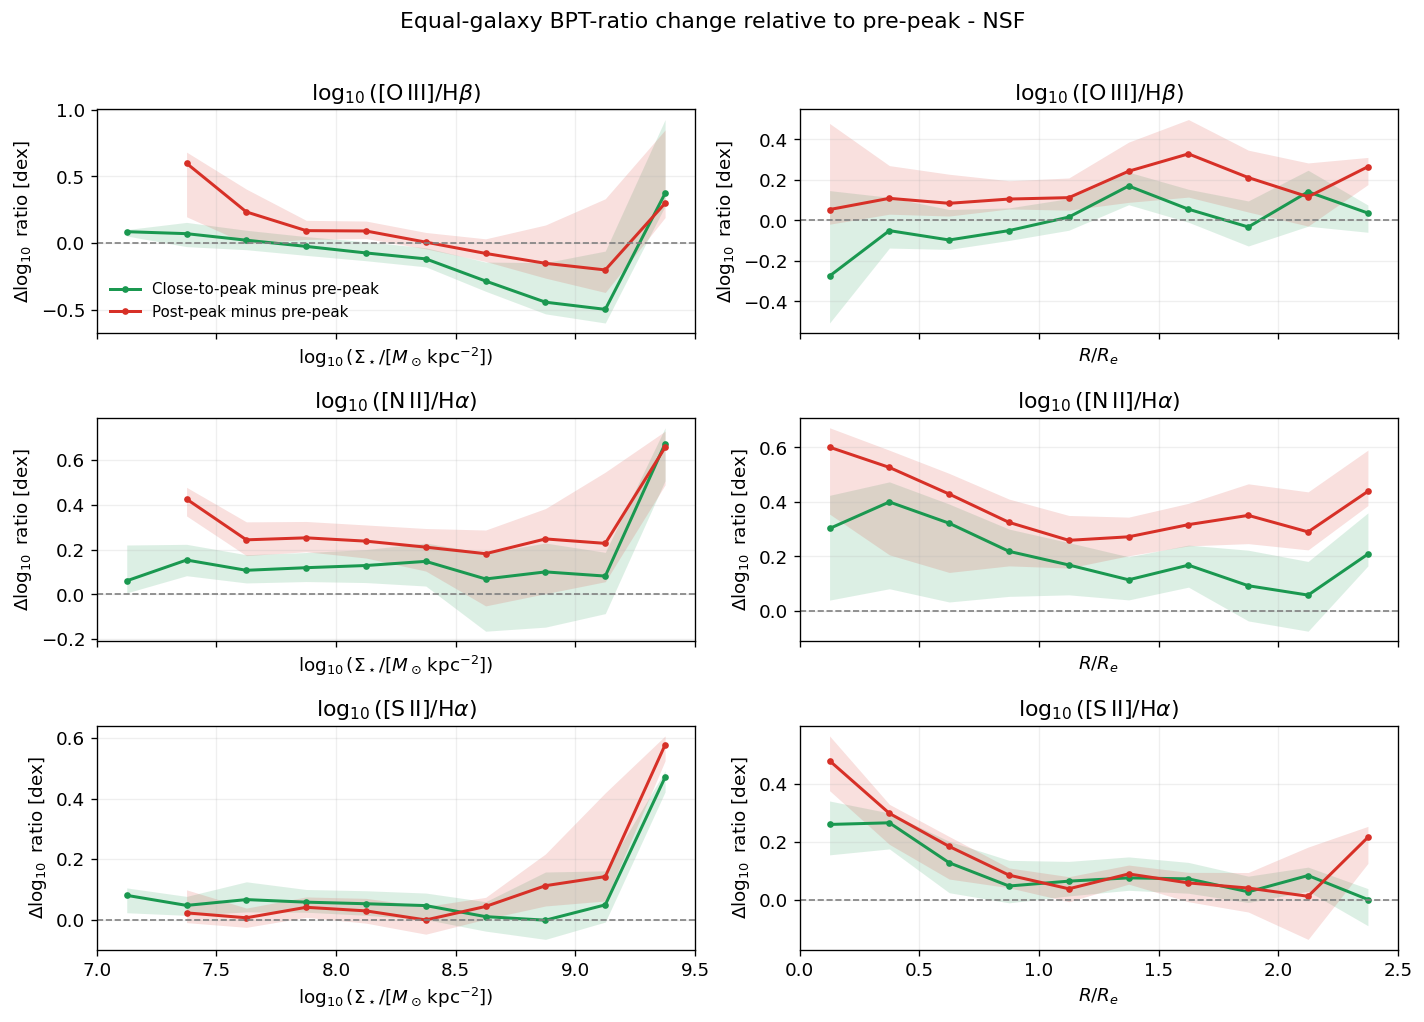

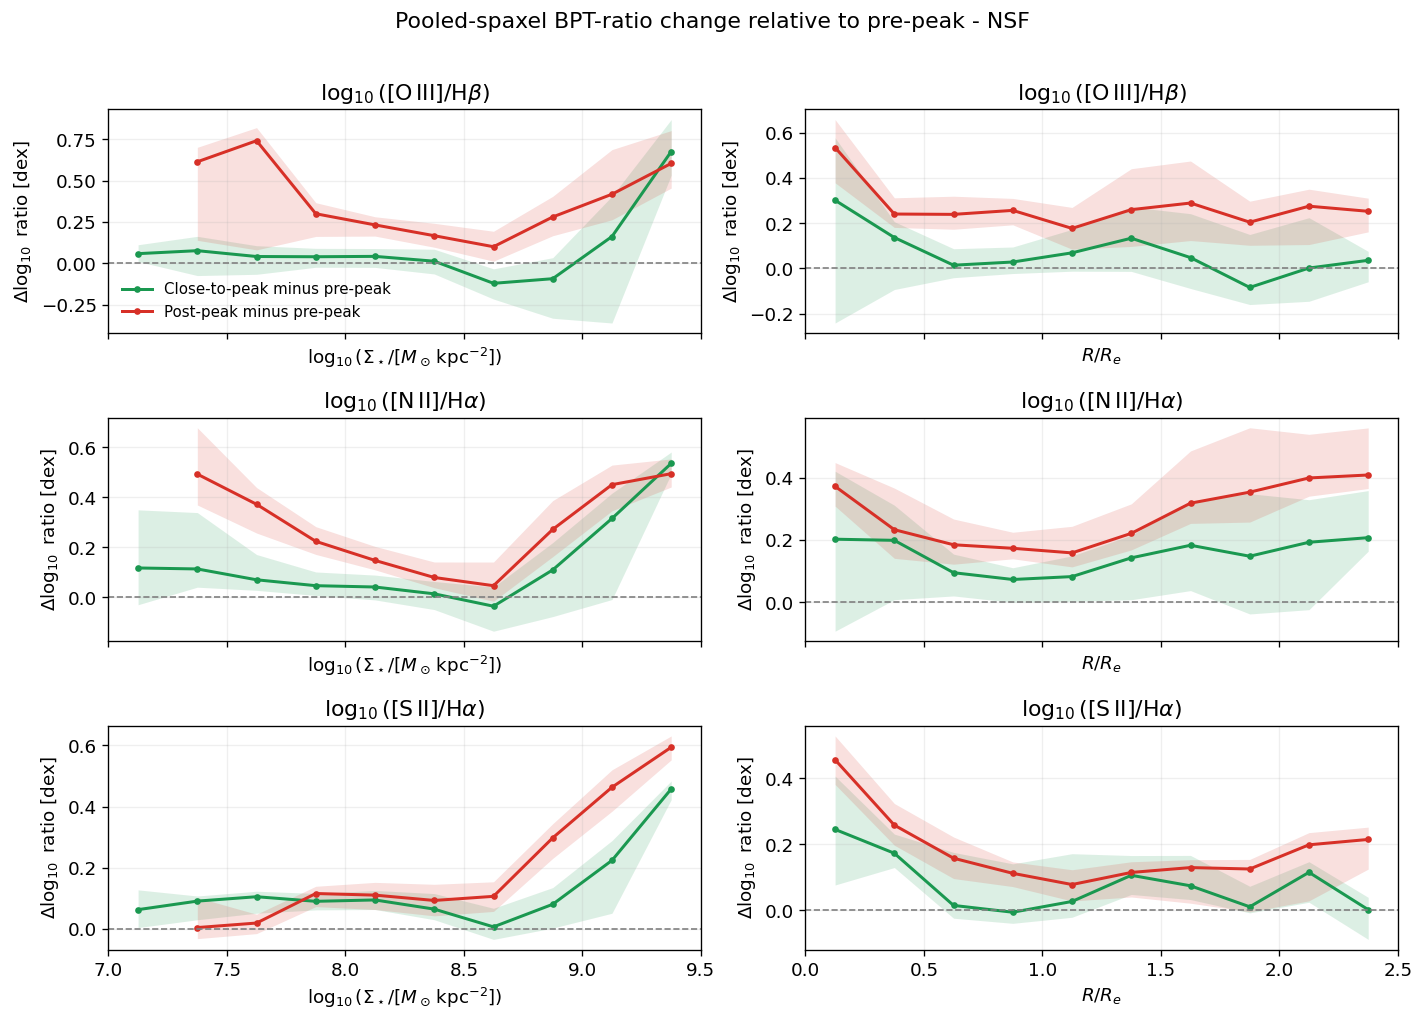

In [13]:
show_ratios("NSF", contrast=True)

## Intrinsic H$\alpha$ dispersion: NSF
Means use finite intrinsic dispersion on the NSF footprint. NSF has no imposed upper dispersion cut.

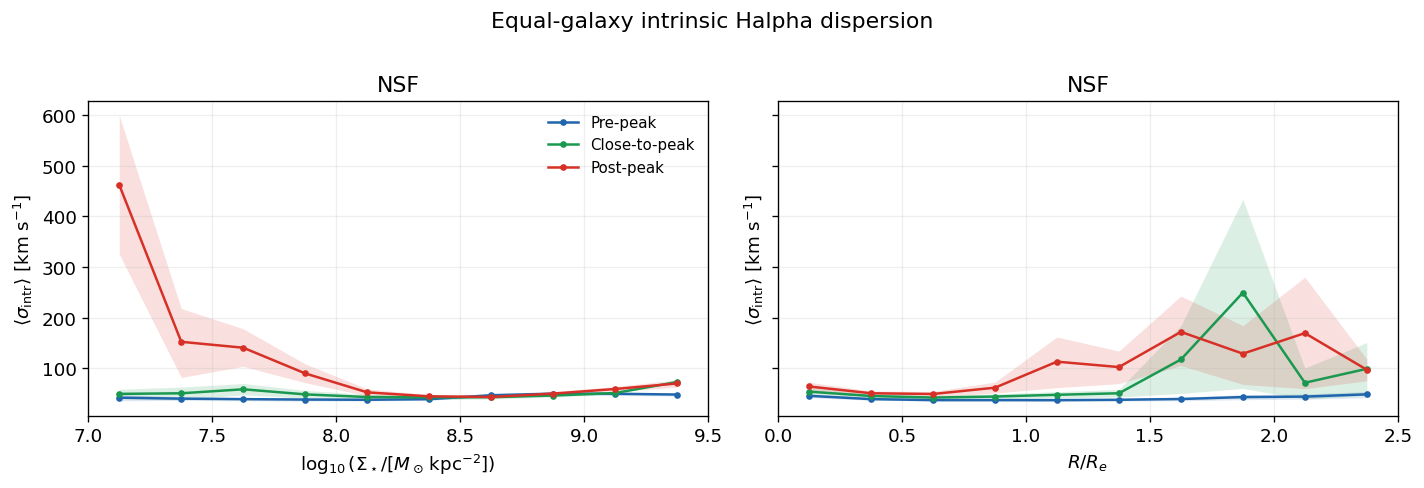

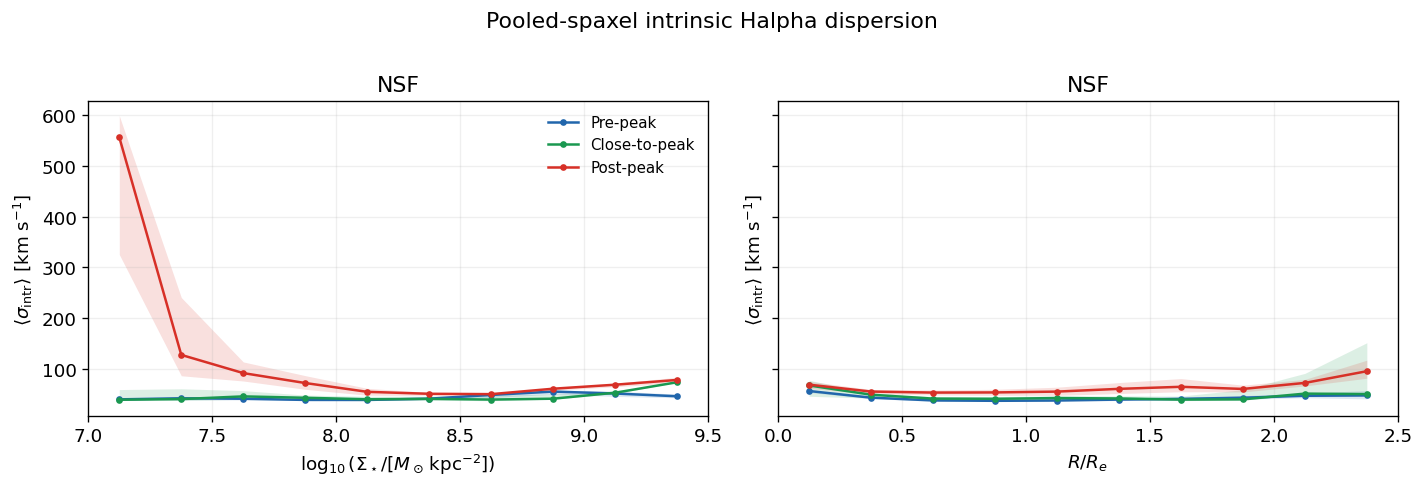

In [14]:
show_sigma()

## Intrinsic H$\alpha$ dispersion changes relative to pre-peak
Positive values indicate broader lines within the selected category. These comparisons cannot uniquely identify a physical excitation mechanism.

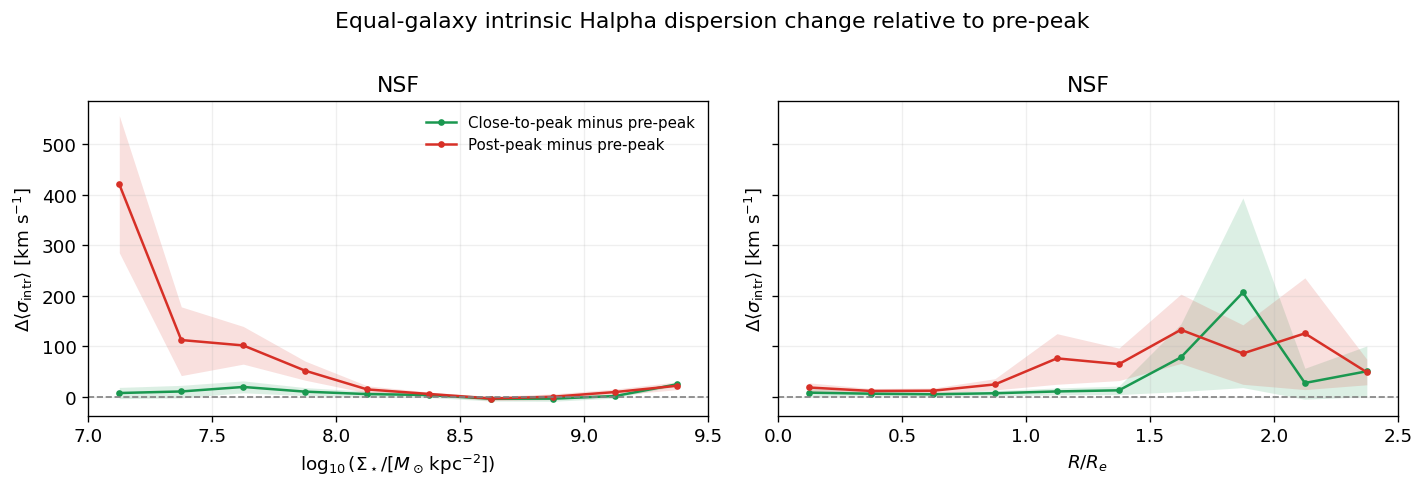

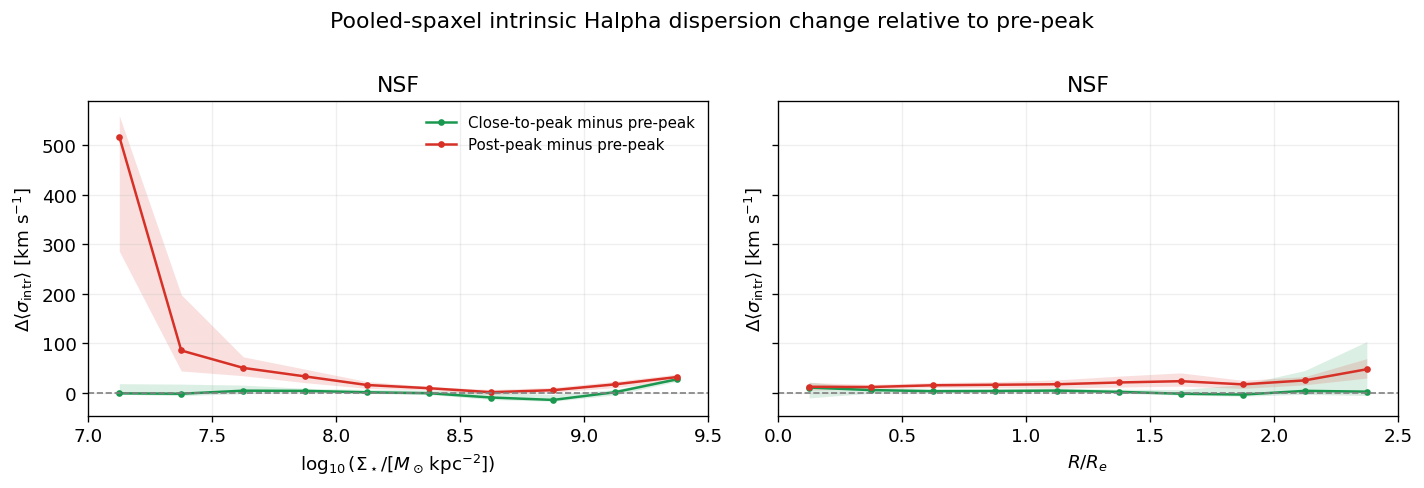

In [15]:
show_sigma(contrast=True)

## Numerical checks and descriptive summary
These checks establish internal consistency, not causal evidence. Bin summaries are descriptive; bins within a galaxy are not independent trials.

In [16]:
checks = {"all_three_stages": set(sample.stage) == set(STAGE_ORDER), "strict_snr": bool(all_retained_strict)}
checks["category_partition"] = bool((SNR_SUMMARY.N_SF + SNR_SUMMARY.N_NSF + SNR_SUMMARY.N_ND == SNR_SUMMARY.N_usable).all())
checks["intrinsic_sigma_formula"] = np.allclose(intrinsic_sigma_from_maps(np.array([50., 20., 10.]), np.array([30., 20., 20.])), [40., np.nan, np.nan], equal_nan=True)
checks["nsf_only_in_all_outputs"] = all(set(t.category) == {"NSF"} for tables in (LINE_TABLES, RATIO_TABLES, SIGMA_TABLES, LINE_CONTRASTS, RATIO_CONTRASTS, SIGMA_CONTRASTS) for t in tables.values())
for branch in BRANCH_LABELS:
    table = LINE_TABLES[branch]
    source_estimator = BPT_LINE_PROFILES if branch == "equal" else POOLED_BPT_LINE_PROFILES
    checks[branch + "_bootstrap_central_matches_estimator"] = np.allclose(table.mean_line_surface, source_estimator.set_index(["stage", "variable", "category", "line", "bin_left"]).loc[table.set_index(["stage", "variable", "category", "line", "bin_left"]).index].mean_line_surface, equal_nan=True)
    ratios = RATIO_TABLES[branch]
    lines = table.set_index(["stage", "variable", "category", "line", "bin_left"])
    checks[branch + "_actual_ratio_denominators"] = all(np.isclose(item.value,
        log_positive(lines.loc[(item.stage, item.variable, item.category, item.line, item.bin_left)].mean_line_surface) -
        log_positive(lines.loc[(item.stage, item.variable, item.category, RATIO_DENOMINATORS[item.line], item.bin_left)].mean_line_surface), equal_nan=True)
        for item in ratios.itertuples(index=False))
    for name, tables in (("line", LINE_CONTRASTS), ("ratio", RATIO_CONTRASTS), ("sigma", SIGMA_CONTRASTS)):
        valid = tables[branch].dropna(subset=["value_lo", "value_hi"])
        checks[branch + "_" + name + "_intervals_ordered"] = bool((valid.value_lo <= valid.value_hi).all())
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), checks
summary_rows = []
for observable, tables in (("Line intensity (dex)", LINE_CONTRASTS), ("BPT ratio (dex)", RATIO_CONTRASTS), ("Intrinsic sigma (km/s)", SIGMA_CONTRASTS)):
    for branch, table in tables.items():
        for keys, group in table.loc[table.in_fixed_reliable_range].groupby(["category", "stage", "variable", "line"], observed=True):
            category, stage, variable, line = keys
            summary_rows.append({"observable": observable, "weighting": branch, "category": category,
                "stage_minus_pre": stage, "variable": variable, "line": line,
                "N_finite_bins": int(group.value.notna().sum()), "median_change": group.value.median(),
                "bins_interval_above_zero": int(group.value_lo.gt(0).sum()),
                "bins_interval_below_zero": int(group.value_hi.lt(0).sum())})
RESULT_SUMMARY = pd.DataFrame(summary_rows)
display(RESULT_SUMMARY.round(3))
print("NSF_ONLY_NOTEBOOK_VALIDATION_OK")

,passed
all_three_stages,True
strict_snr,True
category_partition,True
intrinsic_sigma_formula,True
nsf_only_in_all_outputs,True
equal_bootstrap_central_matches_estimator,True
equal_actual_ratio_denominators,True
equal_line_intervals_ordered,True
equal_ratio_intervals_ordered,True
equal_sigma_intervals_ordered,True


,observable,weighting,category,stage_minus_pre,variable,line,N_finite_bins,median_change,bins_interval_above_zero,bins_interval_below_zero
0,Line intensity (dex),equal,NSF,close-to-peak,log_sigma_star,HA6562,10,-0.284,0,7
1,Line intensity (dex),equal,NSF,close-to-peak,log_sigma_star,HB4861,10,-0.284,0,7
2,Line intensity (dex),equal,NSF,close-to-peak,log_sigma_star,NII6583,10,-0.168,0,7
3,Line intensity (dex),equal,NSF,close-to-peak,log_sigma_star,OIII5006,10,-0.401,0,8
4,Line intensity (dex),equal,NSF,close-to-peak,log_sigma_star,SII_SUM,10,-0.232,0,7
...,...,...,...,...,...,...,...,...,...,...
67,Intrinsic sigma (km/s),equal,NSF,post-peak,radius_re,sigma_Ha,10,56.612,10,0
68,Intrinsic sigma (km/s),pooled,NSF,close-to-peak,log_sigma_star,sigma_Ha,10,0.441,2,1
69,Intrinsic sigma (km/s),pooled,NSF,close-to-peak,radius_re,sigma_Ha,10,3.794,3,0
70,Intrinsic sigma (km/s),pooled,NSF,post-peak,log_sigma_star,sigma_Ha,10,24.780,9,0


NSF_ONLY_NOTEBOOK_VALIDATION_OK


### Reading the result

Compare the absolute line profiles with their stage differences before
interpreting a ratio increase: preferential Balmer fading can raise a ratio
without any forbidden-line enhancement. Check NSF along both axes, and compare equal-galaxy with pooled weighting. The latter gives
more weight to galaxies with more supported pixels.

Dispersion differences describe selected NSF populations. NSF can change because
its mixture of failed SF gates changes. Forbidden-line detection also selects a brighter
subset for line comparisons, especially as emission fades. Missing or weakly
supported bins do not establish that the corresponding emission is absent.
Bootstrap bands express between-galaxy sampling variation and do not include
flux, dust-correction, geometry or instrumental-resolution systematics.


## Additional restriction: NSF + EW(Halpha) < 3 Angstrom

This second plot set uses
`NSF_EW3 = NSF & np.isfinite(PROXY_EWHA) & (PROXY_EWHA < 3)`.
The comparison retains the parent NSF mask, strict `SNR_POSTFIT > 25` footprint,
usable-disc denominator, common bin edges, support thresholds, axis ranges and
10,000 whole-galaxy bootstrap draws. No extra dispersion or SII-class cut is added.
Exactly 3 Angstrom and unavailable EW values are excluded.

Measurements are recomputed from the restricted pixels before estimating line
intensities, ratios or dispersion. The original NSF tables remain available;
all additional results use the `EW3_` prefix. Reduced support and retained
fractions are shown before the repeated plots.


In [11]:
EW3_HA_MAX = 3.0
EW3_CATEGORY = "NSF + EW(Halpha)<3"
EW3_CATEGORY_ORDER = (EW3_CATEGORY,)
# Same seed offset as parent NSF for directly comparable resampling.
CATEGORY_SEED_INDEX[EW3_CATEGORY] = CATEGORY_SEED_INDEX["NSF"]
ew3_measurement_rows, ew3_qc_rows = [], []
ew3_exact_selection = True
for galaxy_row in sample.itertuples(index=False):
    maps = load_halpha_category_maps(galaxy_row, geometry)
    keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
    parent = maps["nsf_mask"] & keep
    ew = maps["ew_ha"]
    restricted = parent & np.isfinite(ew) & (ew < EW3_HA_MAX)
    expected = keep & maps["nsf_mask"] & np.isfinite(ew) & (ew < 3.0)
    ew3_exact_selection &= bool(np.array_equal(restricted, expected))
    assert not np.any(restricted & ~parent)
    assert np.all(np.isfinite(ew[restricted]) & (ew[restricted] < 3.0))
    ew3_qc_rows.append({
        "GALID": galaxy_row.GALID, "stage": galaxy_row.stage,
        "N_usable": int(keep.sum()), "N_NSF": int(parent.sum()),
        "N_NSF_EW3": int(restricted.sum()),
        "N_EW_unavailable": int((parent & ~np.isfinite(ew)).sum()),
        "N_EW_ge3": int((parent & np.isfinite(ew) & (ew >= EW3_HA_MAX)).sum()),
    })
    for variable, edges in COMMON_EDGES.items():
        values = maps[variable]
        for lo, hi in zip(edges[:-1], edges[1:]):
            in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
            usable = keep & in_bin
            n_usable = int(usable.sum())
            eligible_usable = n_usable >= MIN_VALID_PIXELS_PER_BIN
            for category in EW3_CATEGORY_ORDER:
                category_mask = restricted & in_bin
                n_category = int(category_mask.sum())
                linear_lha = np.power(10.0, maps["log_lha_surface"][category_mask])
                if linear_lha.size and (
                    not np.isfinite(linear_lha).all() or np.any(linear_lha <= 0)
                ):
                    raise AssertionError(
                        f"{galaxy_row.GALID} {category}: invalid Halpha surface density"
                    )
                sum_lha = float(linear_lha.sum())
                category_support = bool(
                    eligible_usable and n_category >= MIN_CATEGORY_PIXELS_PER_BIN
                )
                record = {
                    "GALID": galaxy_row.GALID,
                    "stage": galaxy_row.stage,
                    "variable": variable,
                    "bin_left": float(lo),
                    "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "category": category,
                    "N_usable": n_usable,
                    "N_category": n_category,
                    "eligible_usable": bool(eligible_usable),
                    "category_support": category_support,
                    "f_category": n_category / n_usable if eligible_usable else np.nan,
                    "sum_lha_within_category": sum_lha,
                    "lha_mean_within_category": (
                        sum_lha / n_category if n_category > 0 else np.nan
                    ),
                    "median_log_lha_within_category": (
                        float(np.nanmedian(maps["log_lha_surface"][category_mask]))
                        if n_category > 0 else np.nan
                    ),
                    "log_lha_values_within_category": np.asarray(
                        maps["log_lha_surface"][category_mask], dtype=np.float32
                    ),
                }
                bpt_common_mask = (
                    category_mask & maps["bpt_common_valid"]
                    if category in EW3_CATEGORY_ORDER
                    else np.zeros(category_mask.shape, dtype=bool)
                )
                n_bpt_common = int(bpt_common_mask.sum())
                record["N_bpt_common"] = n_bpt_common
                record["bpt_common_support"] = bool(
                    eligible_usable
                    and n_bpt_common >= DIAGNOSTIC_MIN_PIXELS_PER_BIN
                )
                for line in BPT_LINE_ORDER:
                    linear_line = np.power(
                        10.0, maps["log_bpt_line_surface"][line][bpt_common_mask]
                    )
                    if linear_line.size and (
                        not np.isfinite(linear_line).all() or np.any(linear_line <= 0)
                    ):
                        raise AssertionError(
                            f"{galaxy_row.GALID} {category} {line}: "
                            "invalid BPT-line surface density"
                        )
                    record[f"sum_{line}_within_category"] = float(linear_line.sum())
                    record[f"mean_{line}_within_category"] = (
                        float(linear_line.mean()) if linear_line.size else np.nan
                    )
                for diagnostic in DIAGNOSTIC_ORDER:
                    diagnostic_mask = (
                        category_mask & maps["diagnostic_valid"][diagnostic]
                        & np.isfinite(maps["diagnostics"][diagnostic])
                    )
                    n_diagnostic = int(diagnostic_mask.sum())
                    record[f"N_{diagnostic}"] = n_diagnostic
                    diagnostic_values = np.asarray(
                        maps["diagnostics"][diagnostic][diagnostic_mask],
                        dtype=np.float32,
                    )
                    record[f"values_{diagnostic}"] = diagnostic_values
                    record[f"median_{diagnostic}"] = (
                        float(np.nanmedian(diagnostic_values))
                        if n_diagnostic > 0 else np.nan
                    )
                ew3_measurement_rows.append(record)
    del maps

EW3_BY_GALAXY_BIN = pd.DataFrame(ew3_measurement_rows)
EW3_SELECTION_QC = pd.DataFrame(ew3_qc_rows)
EW3_SELECTION_QC["fraction_NSF_retained"] = EW3_SELECTION_QC.N_NSF_EW3 / EW3_SELECTION_QC.N_NSF.replace(0, np.nan)
assert (EW3_SELECTION_QC.N_NSF_EW3 + EW3_SELECTION_QC.N_EW_unavailable + EW3_SELECTION_QC.N_EW_ge3 == EW3_SELECTION_QC.N_NSF).all()
EW3_STAGE_QC = EW3_SELECTION_QC.groupby("stage")[["N_usable", "N_NSF", "N_NSF_EW3", "N_EW_unavailable", "N_EW_ge3"]].sum().reindex(STAGE_ORDER)
EW3_STAGE_QC["fraction_NSF_retained"] = EW3_STAGE_QC.N_NSF_EW3 / EW3_STAGE_QC.N_NSF.replace(0, np.nan)
print("NSF + EW(Halpha)<3 selection by galaxy and stage")
display(EW3_SELECTION_QC)
display(EW3_STAGE_QC)


NSF + EW(Halpha)<3 selection by galaxy and stage


,GALID,stage,N_usable,N_NSF,N_NSF_EW3,N_EW_unavailable,N_EW_ge3,fraction_NSF_retained
0,NGC4298,close-to-peak,232720,43104,3424,0,39680,0.079436
1,NGC4424,close-to-peak,144521,37811,10136,0,27675,0.268070
2,NGC4501,close-to-peak,650576,261968,67931,0,194037,0.259310
3,NGC4654,close-to-peak,532883,117845,224,0,117621,0.001901
4,NGC4694,close-to-peak,83090,28137,15323,0,12814,0.544585
5,IC3392,post-peak,57030,9123,5013,0,4110,0.549490
6,NGC4064,post-peak,128406,33921,17960,0,15961,0.529466
7,NGC4293,post-peak,253797,63400,59981,0,3419,0.946073
8,NGC4380,post-peak,233695,51190,9079,0,42111,0.177359
9,NGC4394,post-peak,174723,45294,22660,0,22634,0.500287


,N_usable,N_NSF,N_NSF_EW3,N_EW_unavailable,N_EW_ge3,fraction_NSF_retained
stage,,,,,,
pre-peak,2703316,929104,130723,0,798381,0.140698
close-to-peak,1643790,488865,97038,0,391827,0.198497
post-peak,2825159,815887,500179,0,315708,0.613049


In [12]:
EW3_EQUAL_ESTIMATOR = stage_bpt_line_estimator(EW3_BY_GALAXY_BIN, category_order=EW3_CATEGORY_ORDER)
EW3_POOLED_ESTIMATOR = pooled_bpt_line_estimator(EW3_BY_GALAXY_BIN, category_order=EW3_CATEGORY_ORDER)
EW3_LINE_TABLES, EW3_LINE_DRAWS = {}, {}
EW3_LINE_TABLES["equal"], EW3_LINE_DRAWS["equal"] = bootstrap_bpt_line_profiles(
    EW3_BY_GALAXY_BIN, category_order=EW3_CATEGORY_ORDER, profiles=EW3_EQUAL_ESTIMATOR)
EW3_LINE_TABLES["pooled"], EW3_LINE_DRAWS["pooled"] = bootstrap_pooled_bpt_line_profiles(
    EW3_BY_GALAXY_BIN, category_order=EW3_CATEGORY_ORDER, profiles=EW3_POOLED_ESTIMATOR)
EW3_RATIO_TABLES, EW3_RATIO_DRAWS = {}, {}
for branch in BRANCH_LABELS:
    EW3_RATIO_TABLES[branch], EW3_RATIO_DRAWS[branch] = build_ratio_profiles(EW3_LINE_TABLES[branch], EW3_LINE_DRAWS[branch])
EW3_SIGMA_TABLES, EW3_SIGMA_DRAWS = bootstrap_sigma_profiles(EW3_BY_GALAXY_BIN, category_order=EW3_CATEGORY_ORDER)
EW3_LINE_CONTRASTS = {b: stage_contrasts(EW3_LINE_TABLES[b], EW3_LINE_DRAWS[b], "mean_line_surface", logarithmic=True) for b in BRANCH_LABELS}
EW3_RATIO_CONTRASTS = {b: stage_contrasts(EW3_RATIO_TABLES[b], EW3_RATIO_DRAWS[b], "value") for b in BRANCH_LABELS}
EW3_SIGMA_CONTRASTS = {b: stage_contrasts(EW3_SIGMA_TABLES[b], EW3_SIGMA_DRAWS[b], "value") for b in BRANCH_LABELS}
EW3_SUPPORT_TABLE = pd.concat([
    EW3_LINE_TABLES["equal"].loc[EW3_LINE_TABLES["equal"].line.eq("HA6562")].assign(observable="Common BPT lines"),
    EW3_SIGMA_TABLES["equal"].assign(observable="Intrinsic Halpha sigma")], ignore_index=True)
display(EW3_SUPPORT_TABLE.loc[EW3_SUPPORT_TABLE.in_fixed_reliable_range,
    ["observable", "category", "stage", "variable", "center", "N_gal_support"]])


,observable,category,stage,variable,center,N_gal_support
5,Common BPT lines,NSF + EW(Halpha)<3,pre-peak,log_sigma_star,7.125,0
6,Common BPT lines,NSF + EW(Halpha)<3,pre-peak,log_sigma_star,7.375,0
7,Common BPT lines,NSF + EW(Halpha)<3,pre-peak,log_sigma_star,7.625,2
8,Common BPT lines,NSF + EW(Halpha)<3,pre-peak,log_sigma_star,7.875,4
9,Common BPT lines,NSF + EW(Halpha)<3,pre-peak,log_sigma_star,8.125,4
...,...,...,...,...,...,...
297,Intrinsic Halpha sigma,NSF + EW(Halpha)<3,post-peak,radius_re,1.375,11
298,Intrinsic Halpha sigma,NSF + EW(Halpha)<3,post-peak,radius_re,1.625,8
299,Intrinsic Halpha sigma,NSF + EW(Halpha)<3,post-peak,radius_re,1.875,6
300,Intrinsic Halpha sigma,NSF + EW(Halpha)<3,post-peak,radius_re,2.125,4


### Absolute line surface densities: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


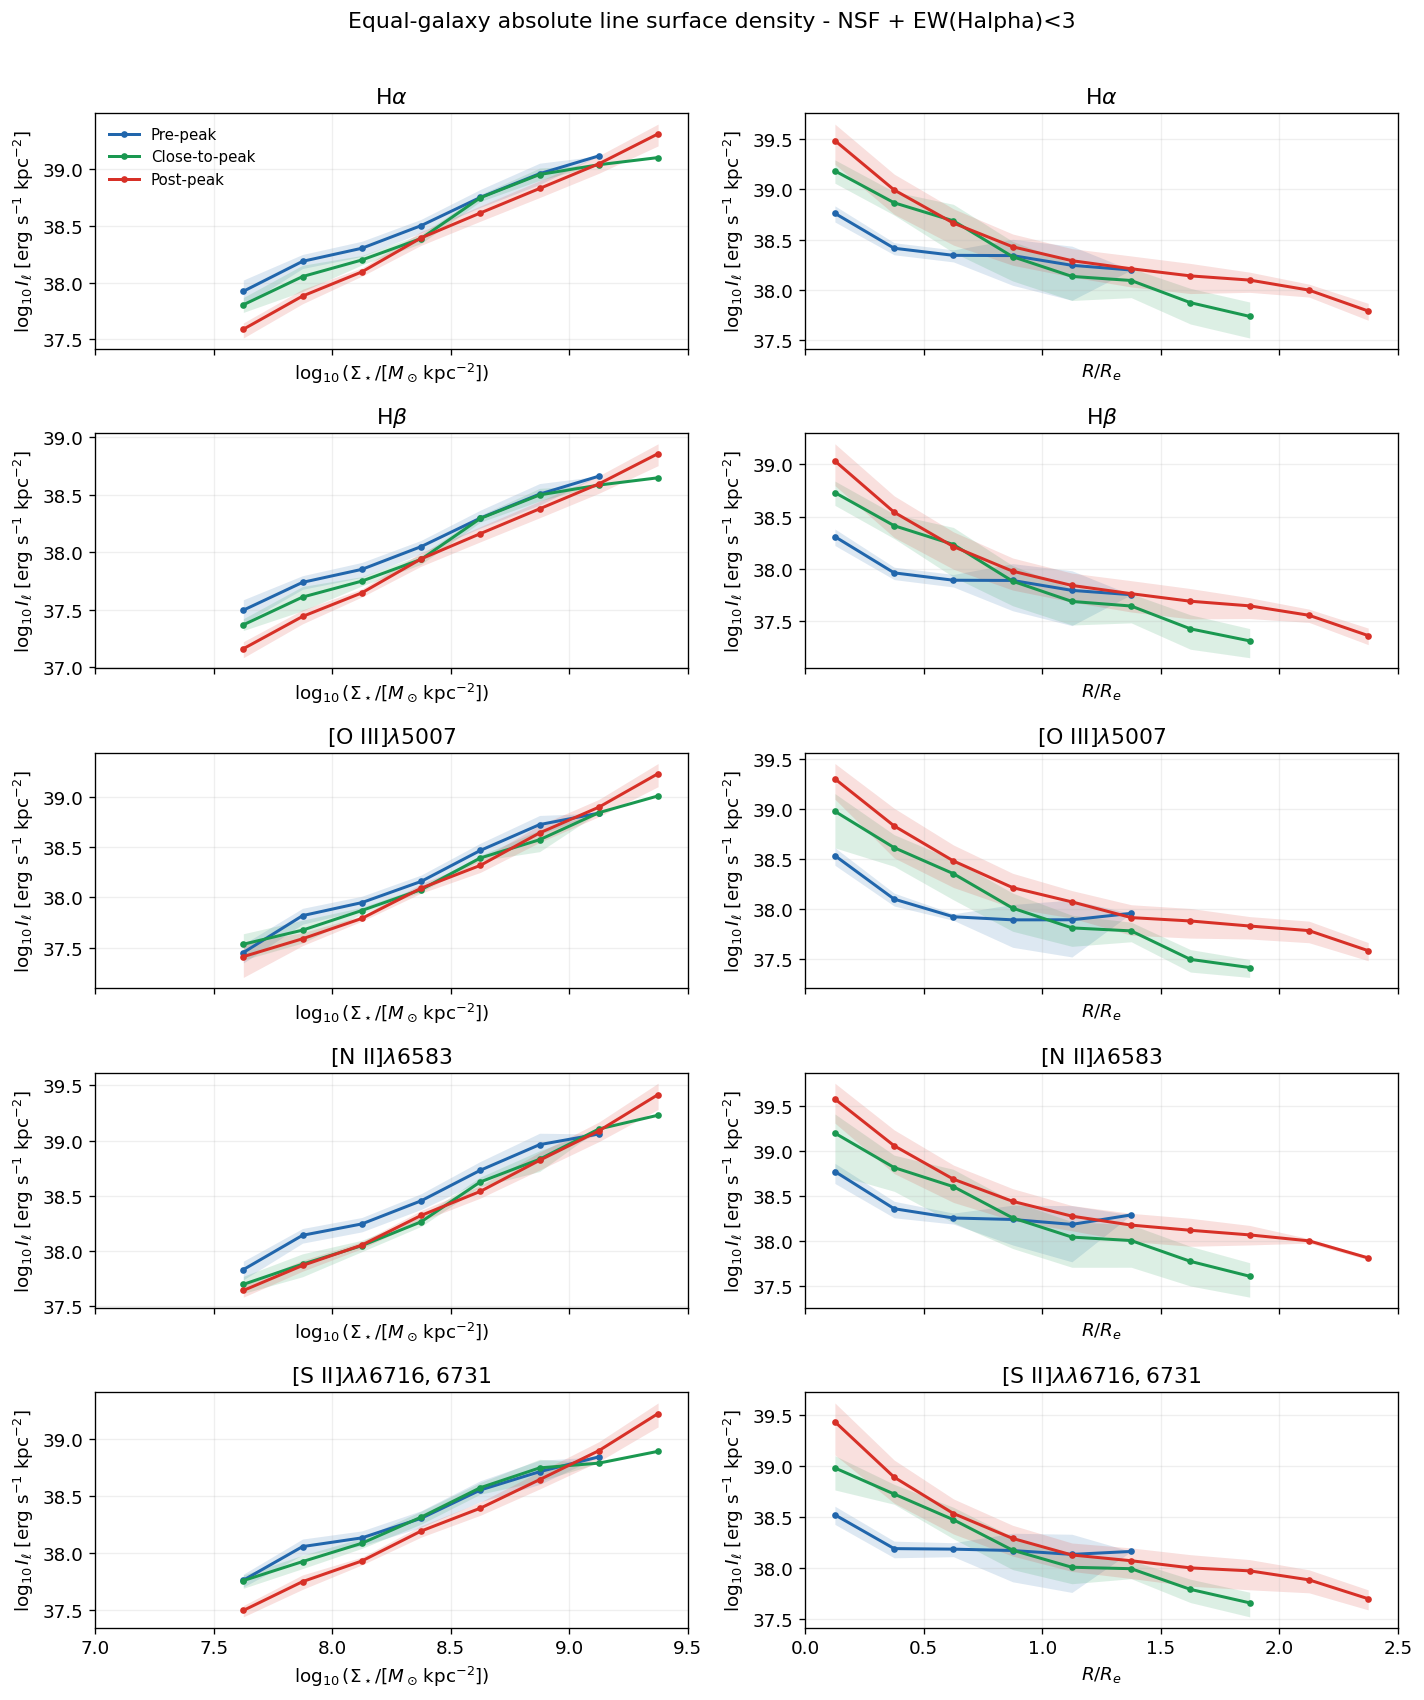

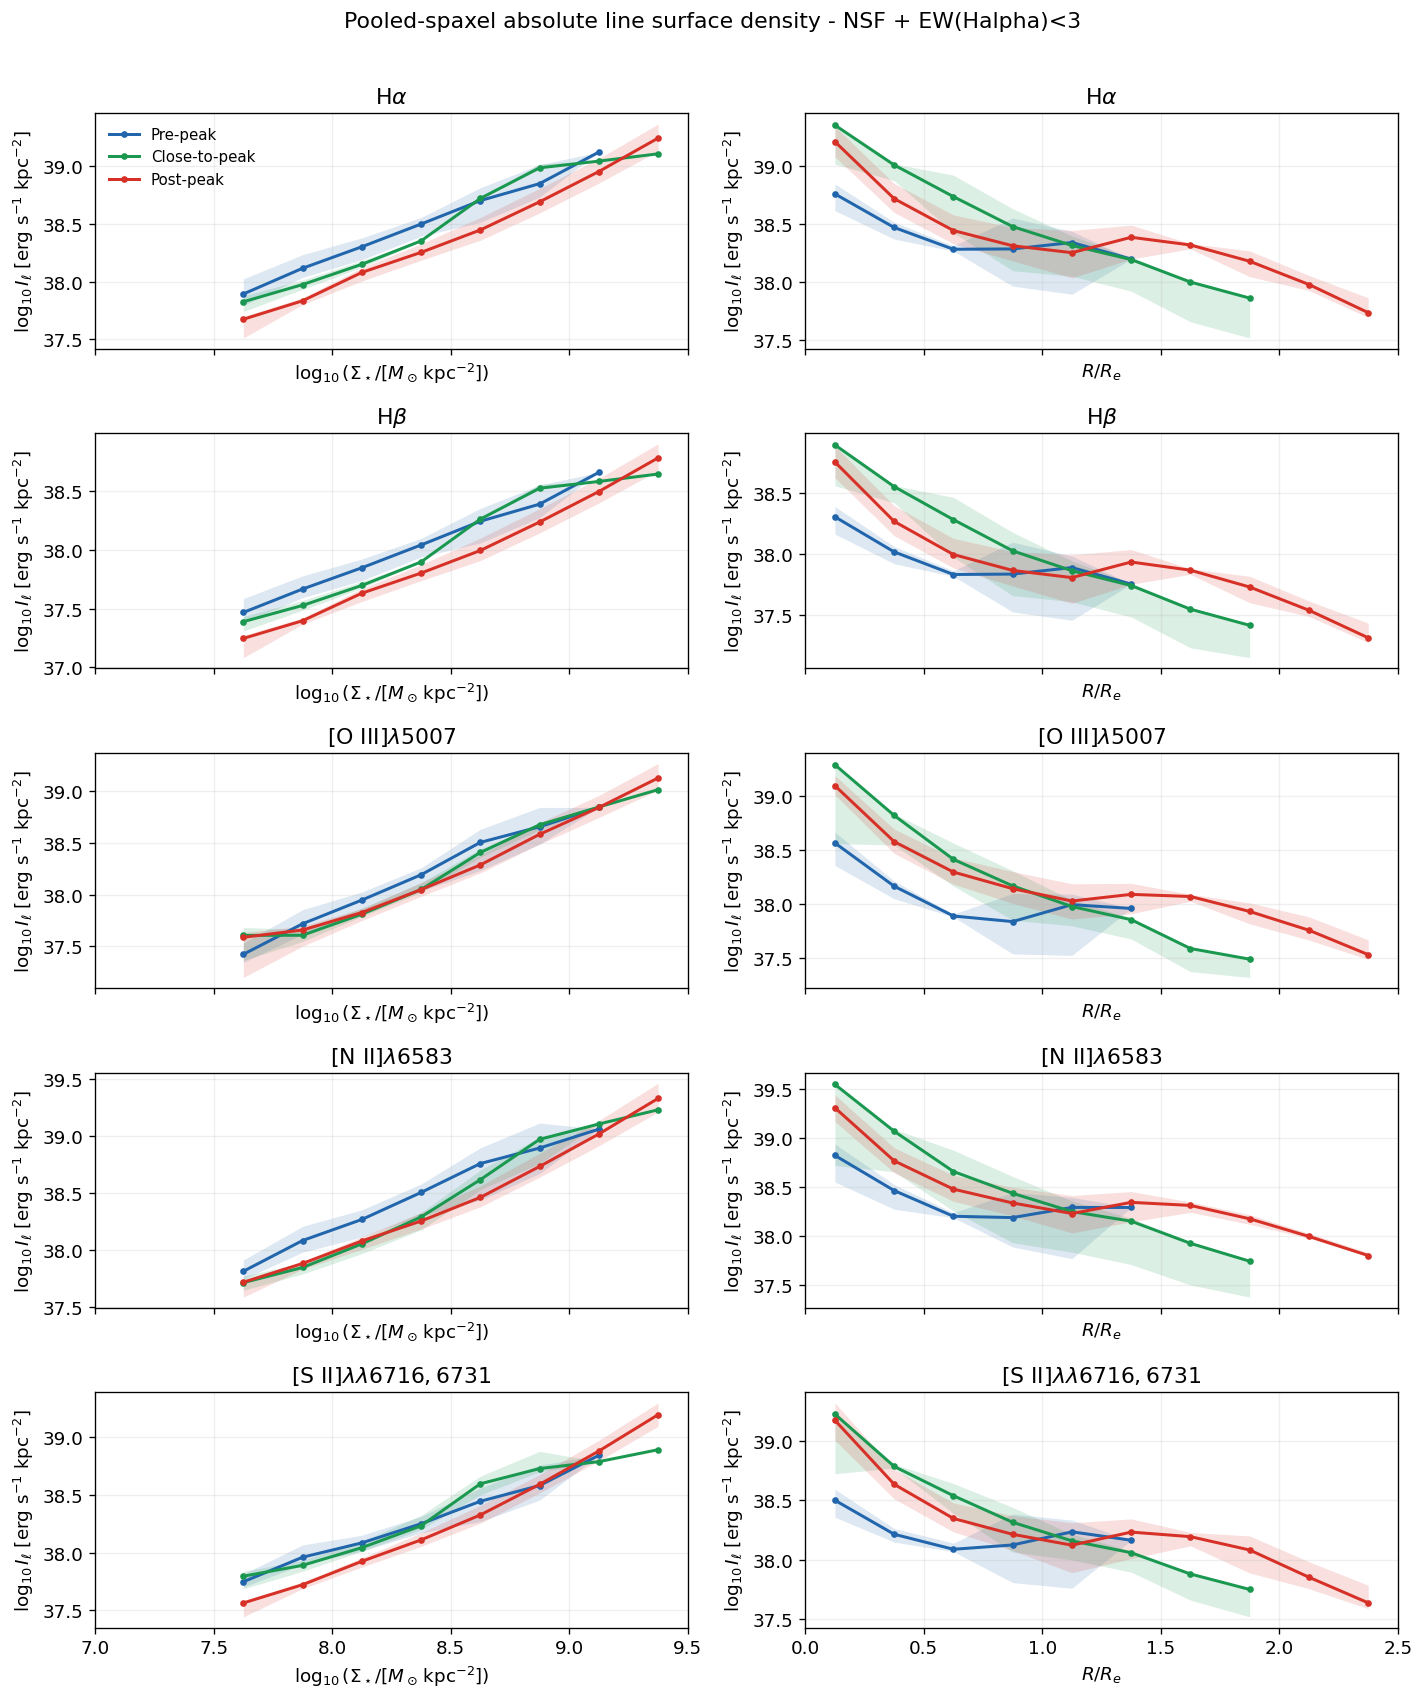

In [13]:
show_lines(EW3_CATEGORY, tables=EW3_LINE_TABLES, contrasts=EW3_LINE_CONTRASTS)


### Absolute line changes relative to pre-peak: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


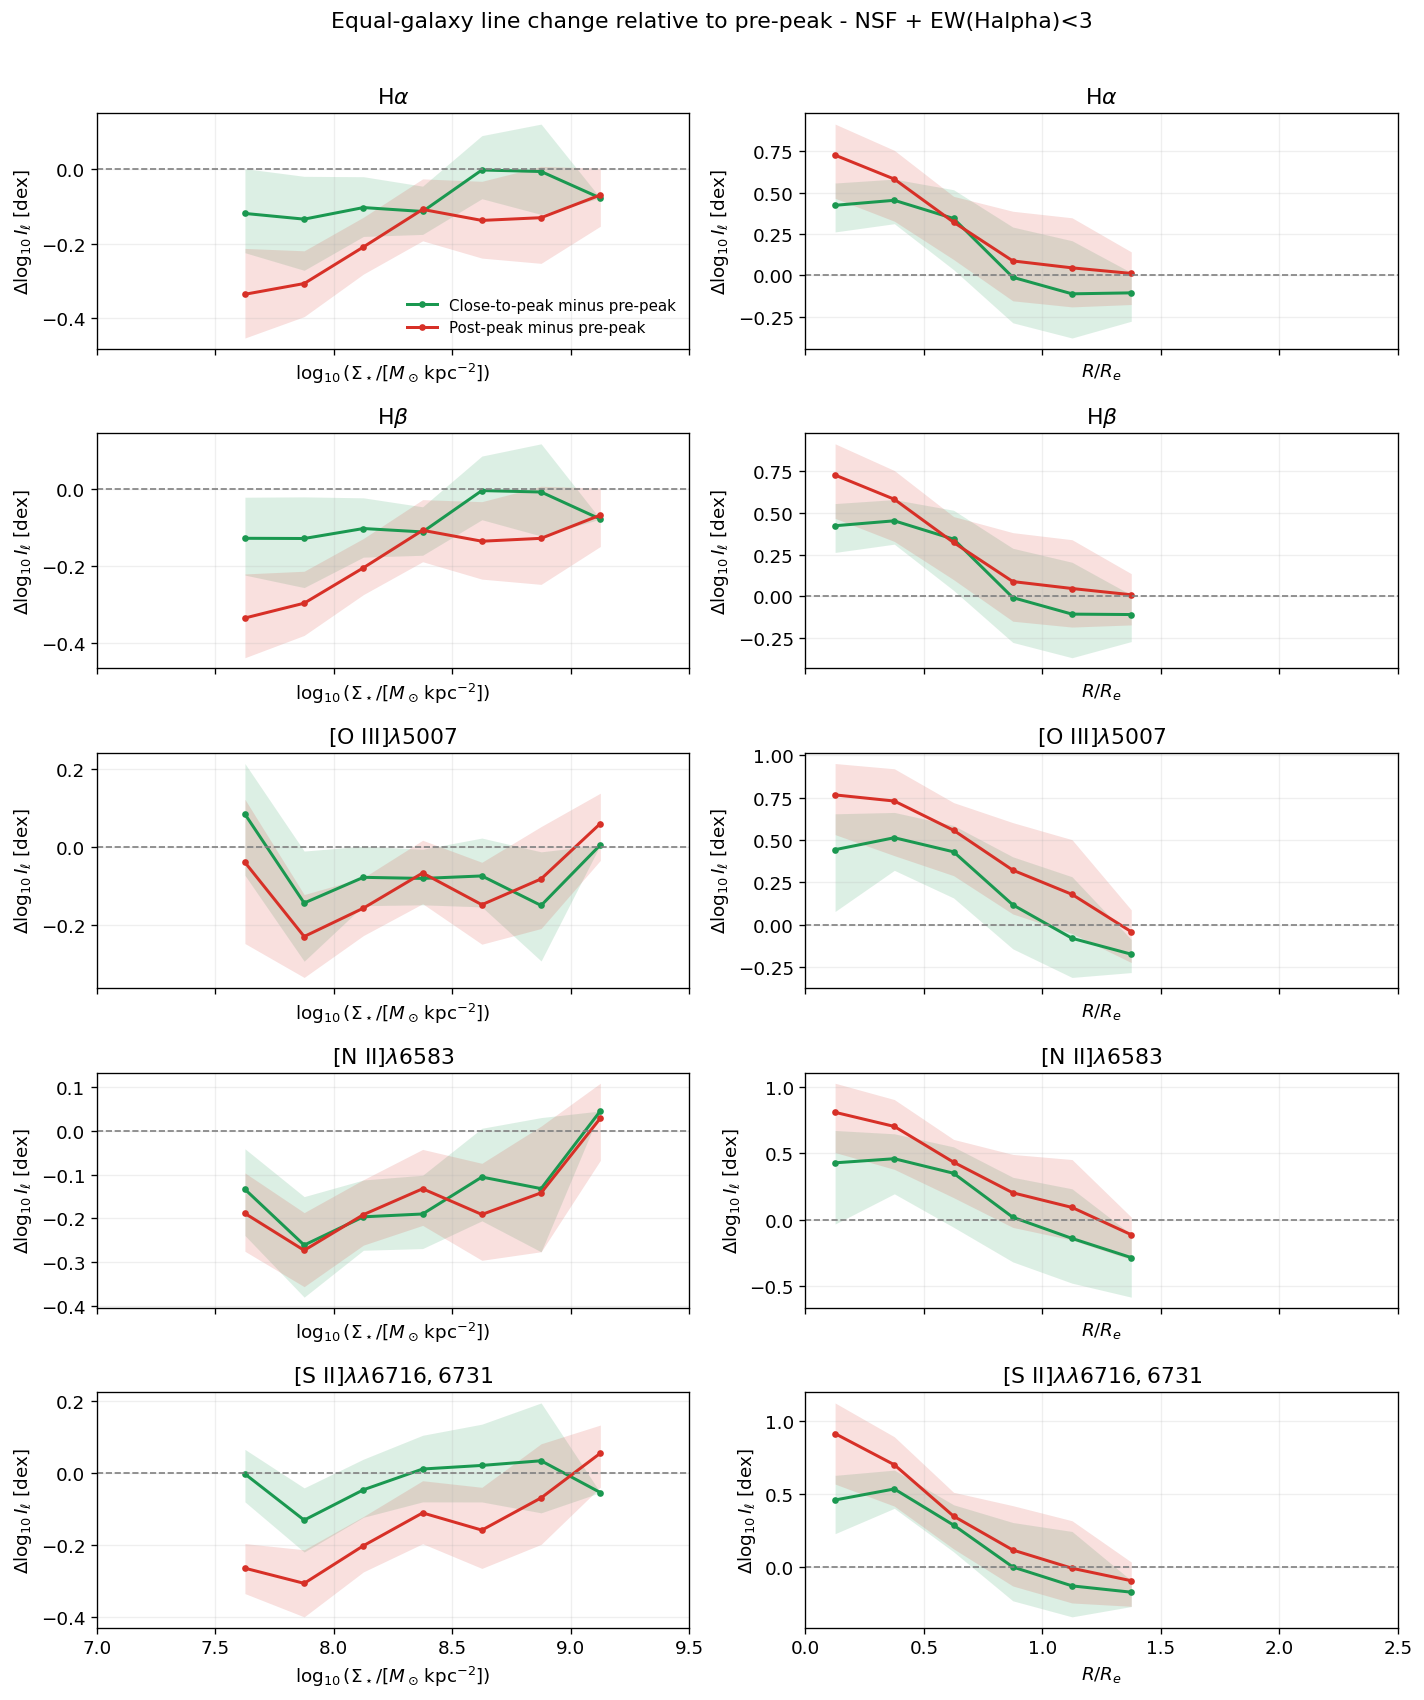

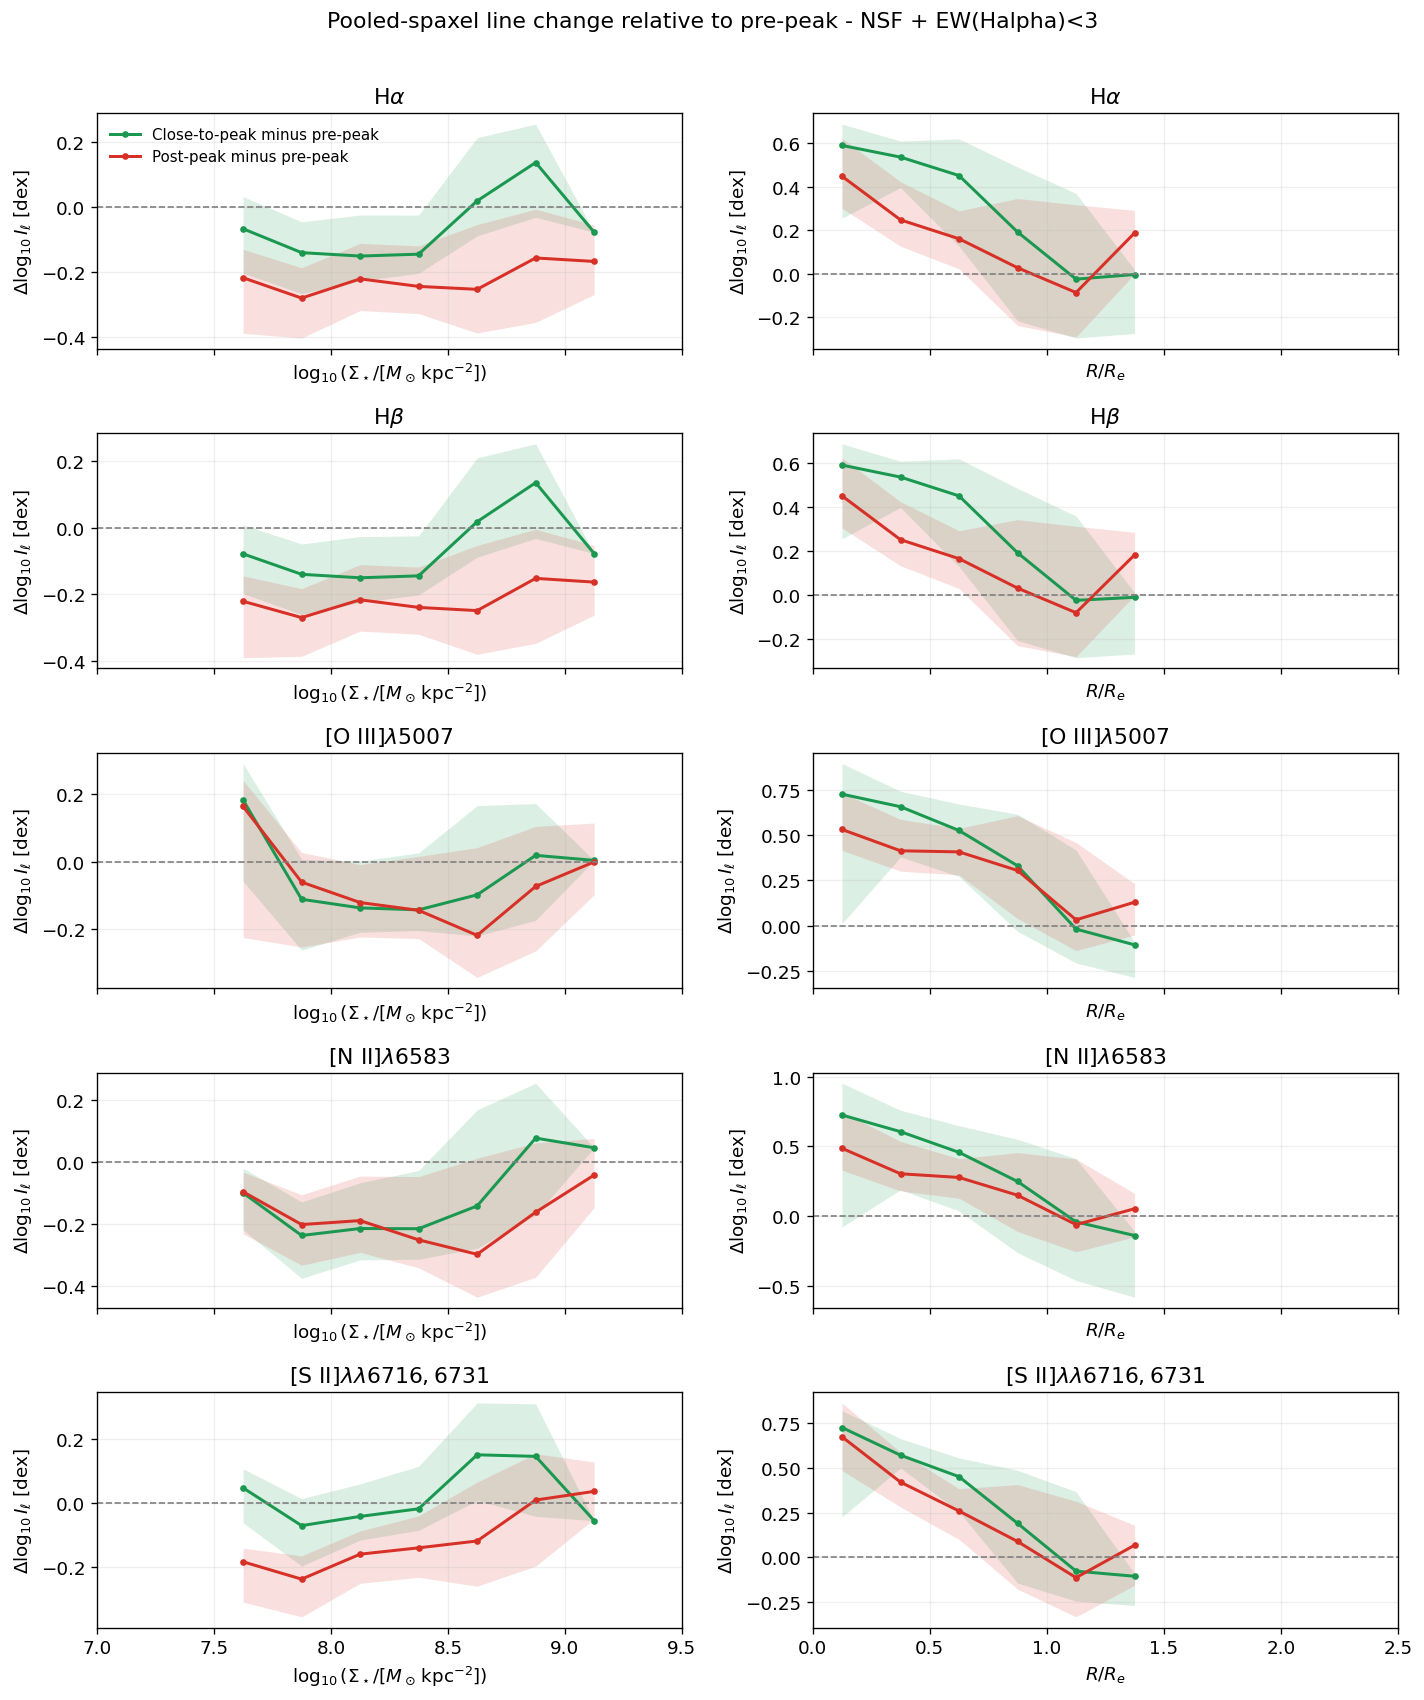

In [14]:
show_lines(EW3_CATEGORY, contrast=True, tables=EW3_LINE_TABLES, contrasts=EW3_LINE_CONTRASTS)


### BPT-ratio profiles: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


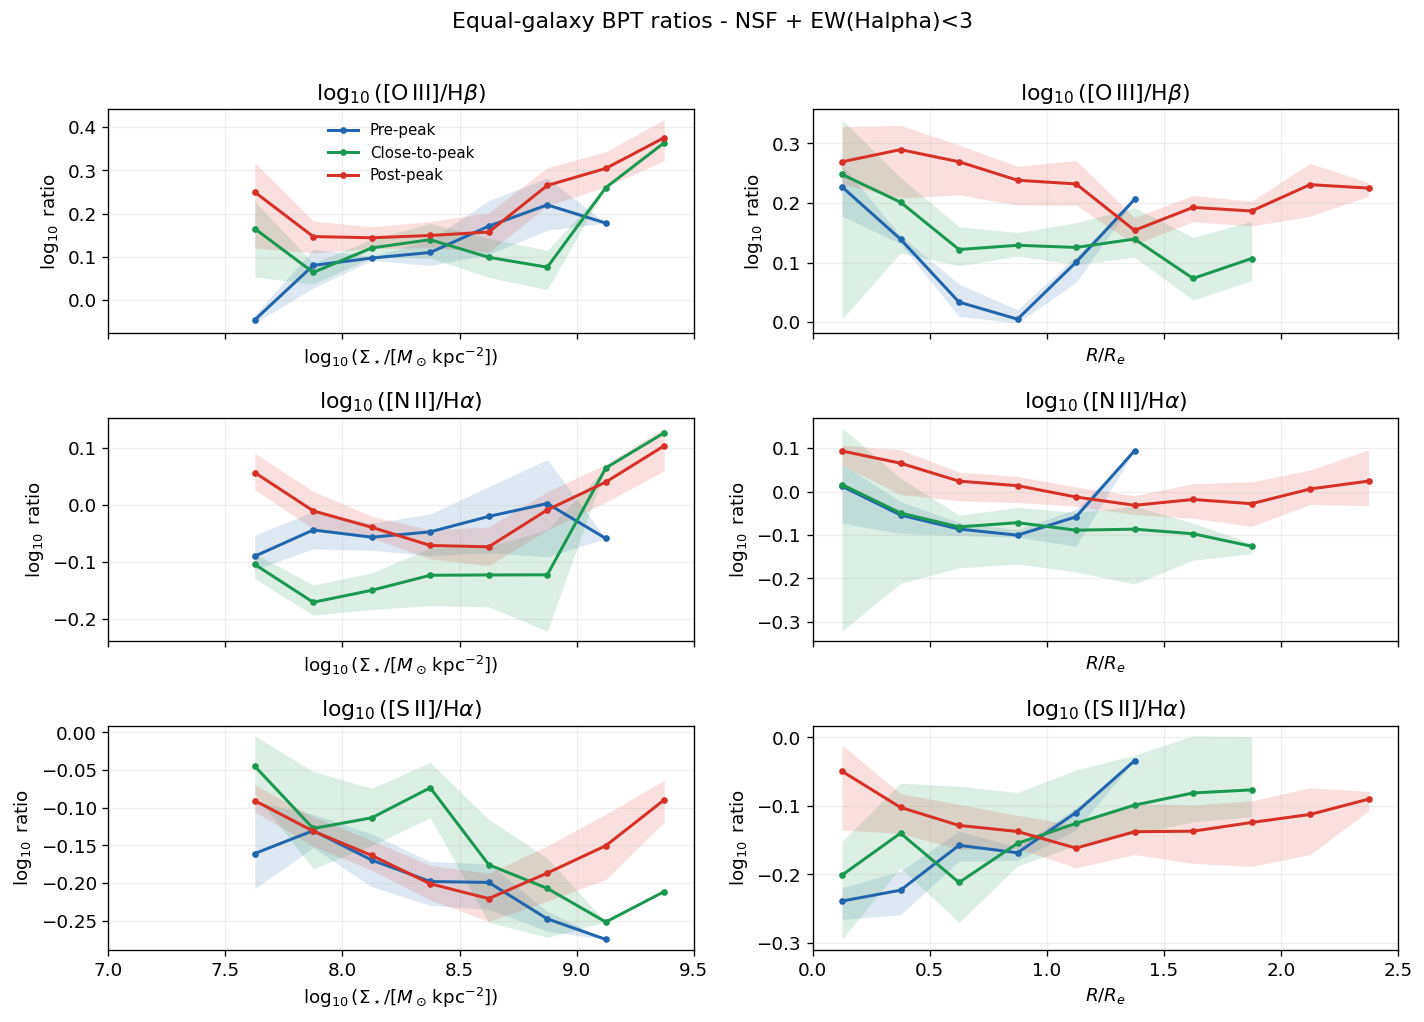

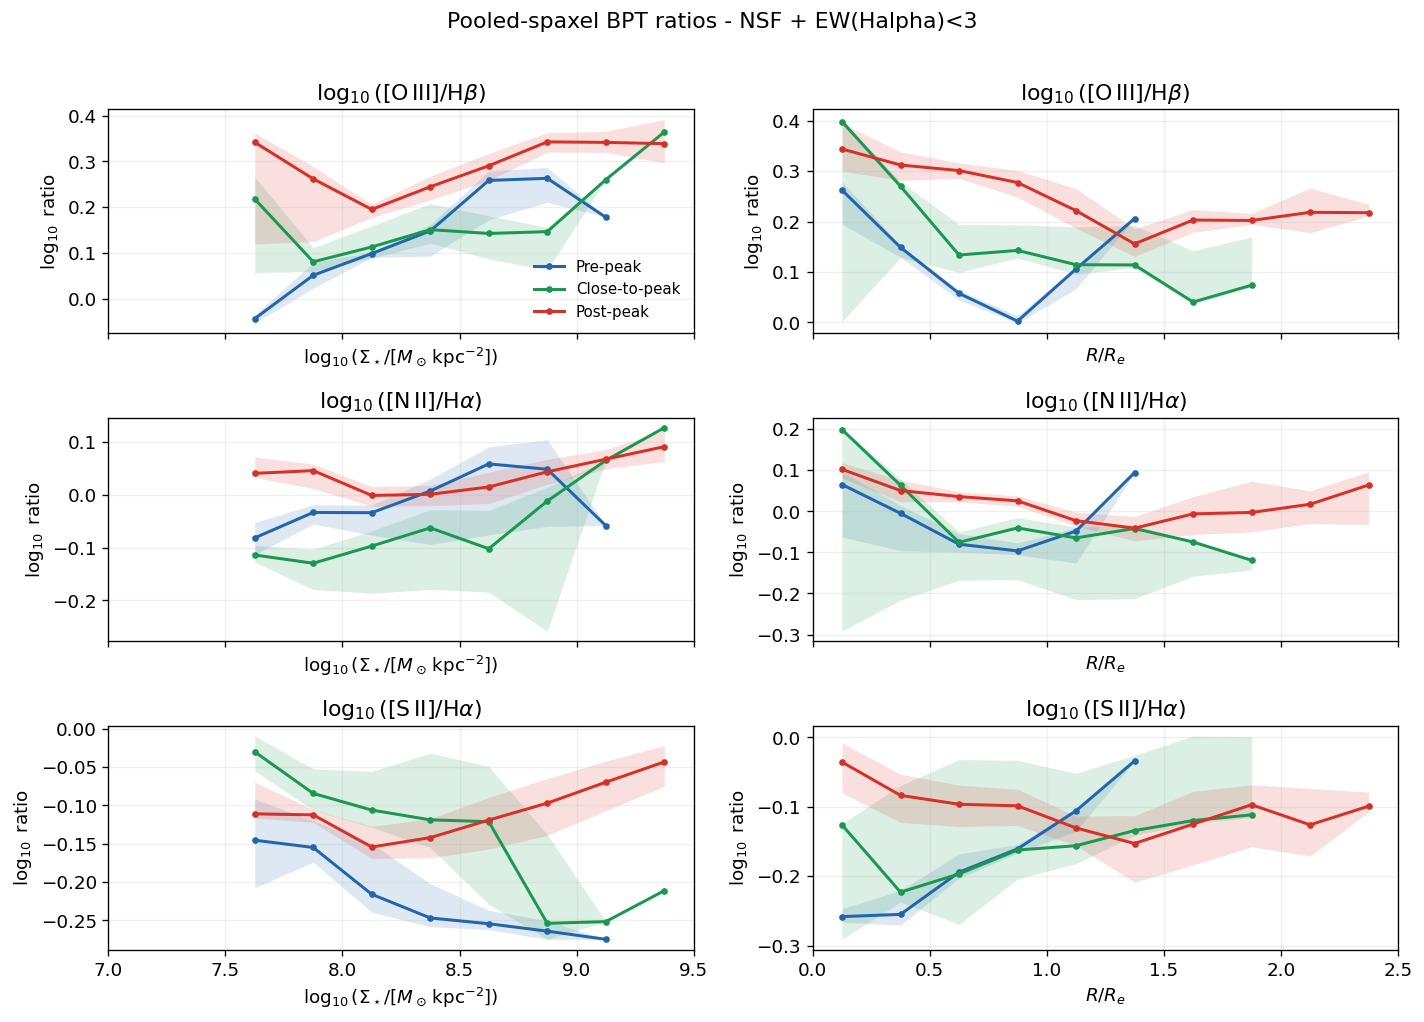

In [15]:
show_ratios(EW3_CATEGORY, tables=EW3_RATIO_TABLES, contrasts=EW3_RATIO_CONTRASTS)


### BPT-ratio changes relative to pre-peak: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


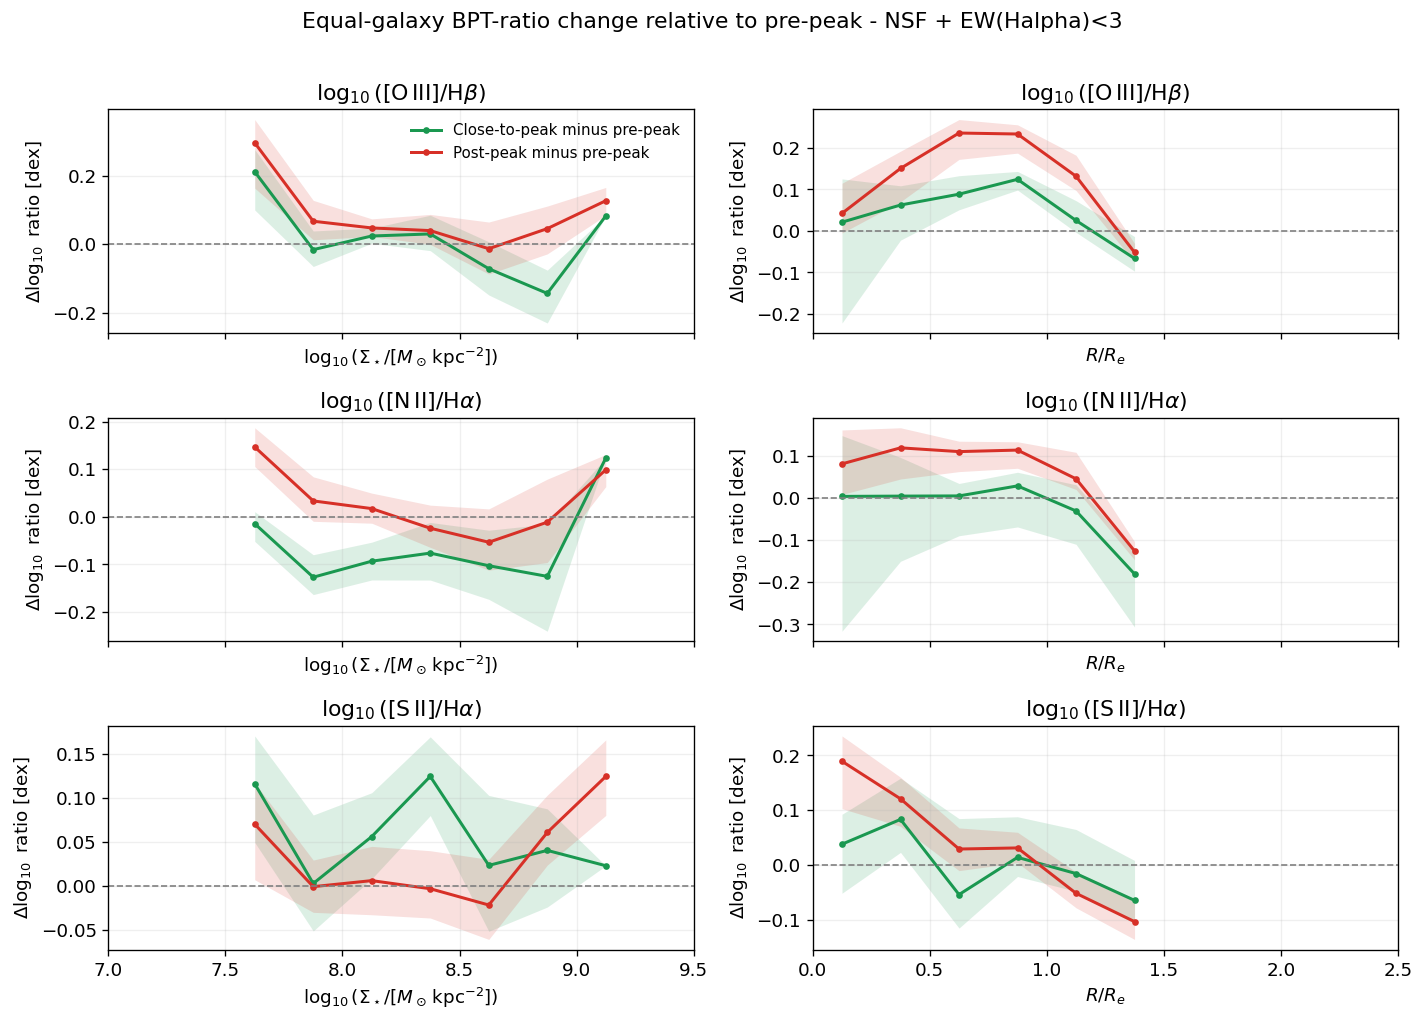

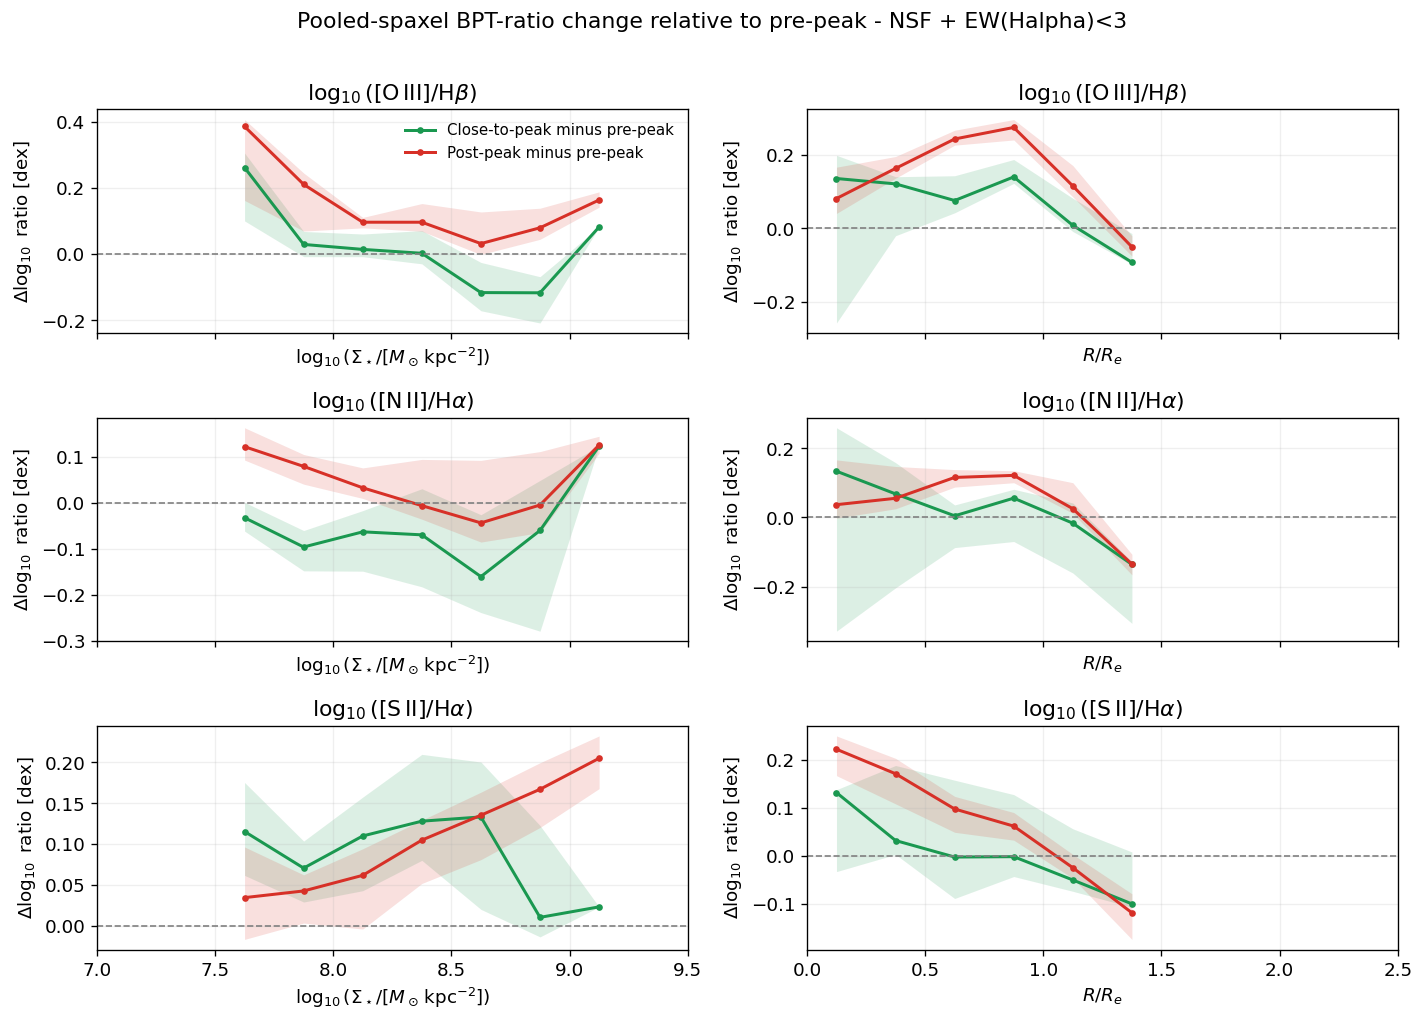

In [16]:
show_ratios(EW3_CATEGORY, contrast=True, tables=EW3_RATIO_TABLES, contrasts=EW3_RATIO_CONTRASTS)


### Intrinsic Halpha dispersion: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


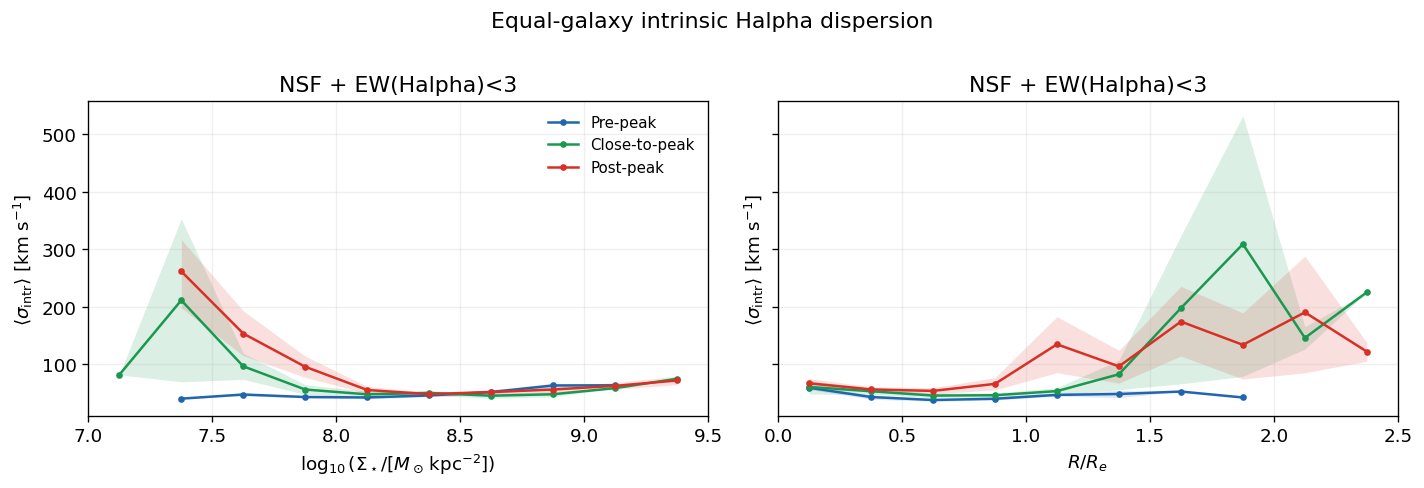

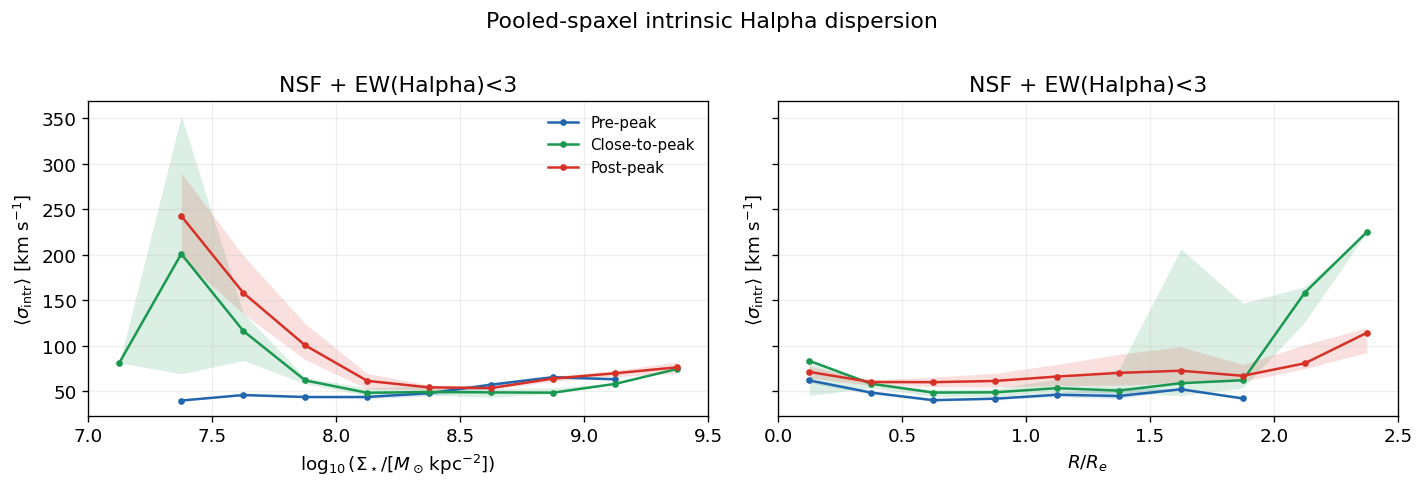

In [17]:
show_sigma(category_order=EW3_CATEGORY_ORDER, tables=EW3_SIGMA_TABLES, contrasts=EW3_SIGMA_CONTRASTS)


### Intrinsic Halpha dispersion changes relative to pre-peak: NSF + EW(Halpha)<3

Equal-galaxy result followed by pooled-spaxel sensitivity.


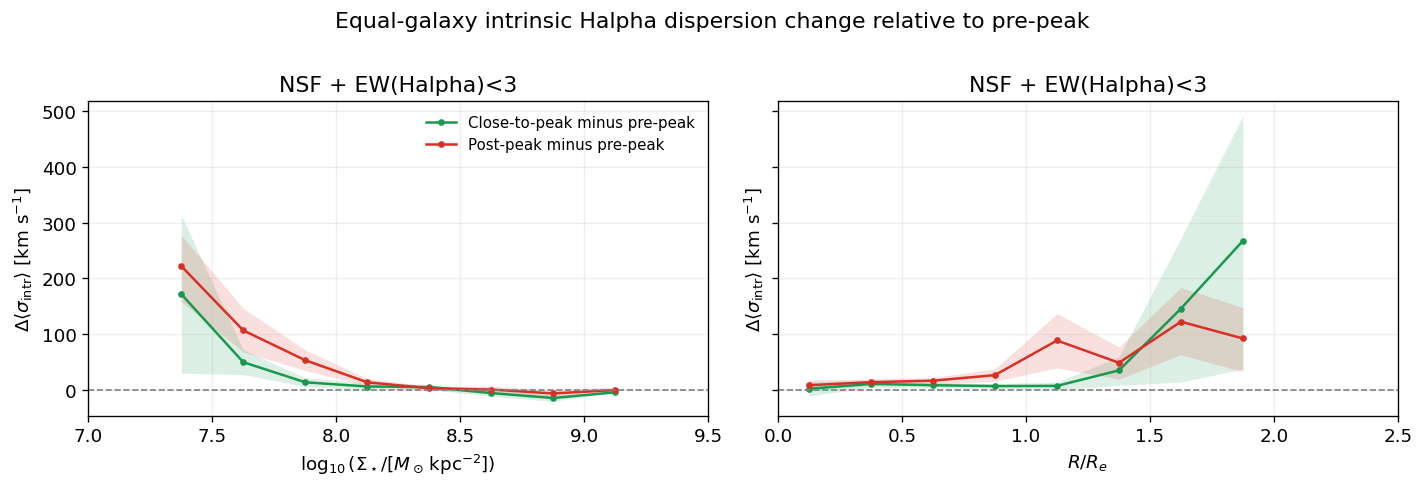

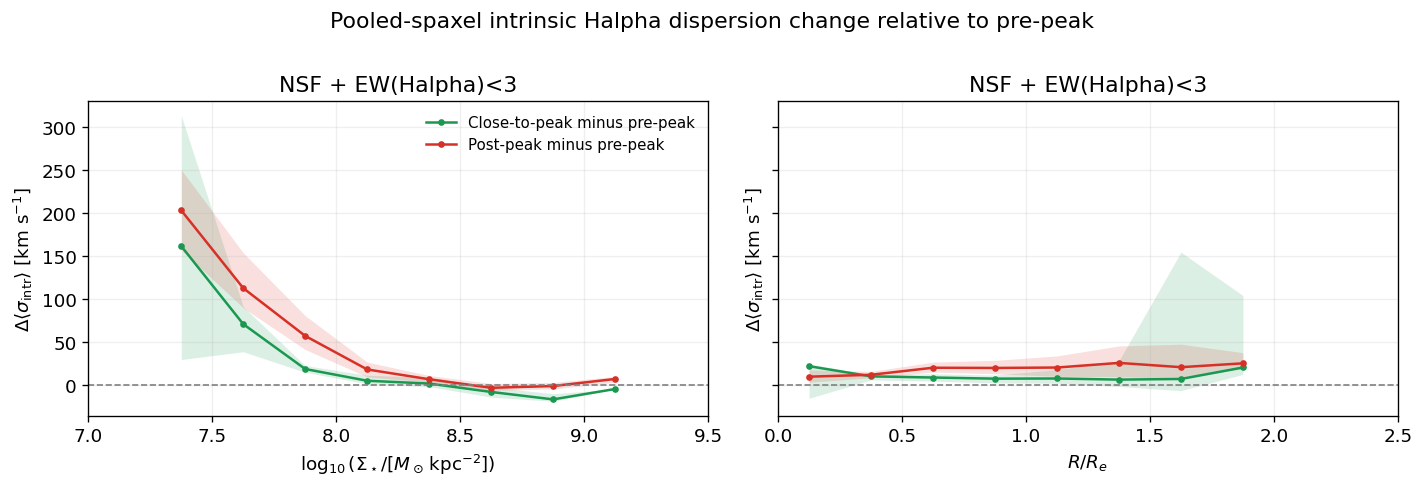

In [18]:
show_sigma(contrast=True, category_order=EW3_CATEGORY_ORDER, tables=EW3_SIGMA_TABLES, contrasts=EW3_SIGMA_CONTRASTS)


### Restricted-sample numerical checks and summary

Sparse bins retain the same support policy as the original NSF plots.


In [19]:
EW3_checks = {
    "exact_nsf_ew_lt3_selection": bool(ew3_exact_selection),
    "subset_counts": bool((EW3_SELECTION_QC.N_NSF_EW3 <= EW3_SELECTION_QC.N_NSF).all()),
    "parent_counts_unchanged": bool(EW3_SELECTION_QC.set_index("GALID").N_NSF.equals(SNR_SUMMARY.set_index("GALID").N_NSF)),
    "usable_denominator_unchanged": bool(EW3_SELECTION_QC.set_index("GALID").N_usable.equals(SNR_SUMMARY.set_index("GALID").N_usable)),
    "only_restricted_category": all(set(t.category) == {EW3_CATEGORY} for tables in (EW3_LINE_TABLES, EW3_RATIO_TABLES, EW3_SIGMA_TABLES, EW3_LINE_CONTRASTS, EW3_RATIO_CONTRASTS, EW3_SIGMA_CONTRASTS) for t in tables.values()),
}
parent_bins = HALPHA_BY_GALAXY_BIN.set_index(["GALID", "variable", "bin_left"])
restricted_bins = EW3_BY_GALAXY_BIN.set_index(["GALID", "variable", "bin_left"])
EW3_checks["bin_counts_subset"] = bool((restricted_bins.N_category <= parent_bins.N_category).all())
EW3_checks["common_line_counts_subset"] = bool((restricted_bins.N_bpt_common <= parent_bins.N_bpt_common).all())
EW3_checks["bin_denominator_unchanged"] = bool(restricted_bins.N_usable.equals(parent_bins.N_usable))
for branch in BRANCH_LABELS:
    table = EW3_LINE_TABLES[branch]
    source_estimator = EW3_EQUAL_ESTIMATOR if branch == "equal" else EW3_POOLED_ESTIMATOR
    EW3_checks[branch + "_bootstrap_central_matches_estimator"] = np.allclose(table.mean_line_surface, source_estimator.set_index(["stage", "variable", "category", "line", "bin_left"]).loc[table.set_index(["stage", "variable", "category", "line", "bin_left"]).index].mean_line_surface, equal_nan=True)
    ratios = EW3_RATIO_TABLES[branch]
    lines = table.set_index(["stage", "variable", "category", "line", "bin_left"])
    EW3_checks[branch + "_actual_ratio_denominators"] = all(np.isclose(item.value,
        log_positive(lines.loc[(item.stage, item.variable, item.category, item.line, item.bin_left)].mean_line_surface) -
        log_positive(lines.loc[(item.stage, item.variable, item.category, RATIO_DENOMINATORS[item.line], item.bin_left)].mean_line_surface), equal_nan=True)
        for item in ratios.itertuples(index=False))
    for name, tables in (("line", EW3_LINE_CONTRASTS), ("ratio", EW3_RATIO_CONTRASTS), ("sigma", EW3_SIGMA_CONTRASTS)):
        valid = tables[branch].dropna(subset=["value_lo", "value_hi"])
        EW3_checks[branch + "_" + name + "_intervals_ordered"] = bool((valid.value_lo <= valid.value_hi).all())
display(pd.Series(EW3_checks, name="passed").to_frame())
assert all(EW3_checks.values()), EW3_checks
ew3_summary_rows = []
for observable, tables in (("Line intensity (dex)", EW3_LINE_CONTRASTS), ("BPT ratio (dex)", EW3_RATIO_CONTRASTS), ("Intrinsic sigma (km/s)", EW3_SIGMA_CONTRASTS)):
    for branch, table in tables.items():
        for keys, group in table.loc[table.in_fixed_reliable_range].groupby(["category", "stage", "variable", "line"], observed=True):
            category, stage, variable, line = keys
            ew3_summary_rows.append({"observable": observable, "weighting": branch, "category": category,
                "stage_minus_pre": stage, "variable": variable, "line": line,
                "N_finite_bins": int(group.value.notna().sum()), "median_change": group.value.median(),
                "bins_interval_above_zero": int(group.value_lo.gt(0).sum()),
                "bins_interval_below_zero": int(group.value_hi.lt(0).sum())})
EW3_RESULT_SUMMARY = pd.DataFrame(ew3_summary_rows)
display(EW3_RESULT_SUMMARY.round(3))
print("NSF_EW3_NOTEBOOK_VALIDATION_OK")

NSF_EW3_NOTEBOOK_VALIDATION_OK


,passed
exact_nsf_ew_lt3_selection,True
subset_counts,True
parent_counts_unchanged,True
usable_denominator_unchanged,True
only_restricted_category,True
bin_counts_subset,True
common_line_counts_subset,True
bin_denominator_unchanged,True
equal_bootstrap_central_matches_estimator,True
equal_actual_ratio_denominators,True


,observable,weighting,category,stage_minus_pre,variable,line,N_finite_bins,median_change,bins_interval_above_zero,bins_interval_below_zero
0,Line intensity (dex),equal,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,HA6562,7,-0.103,0,4
1,Line intensity (dex),equal,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,HB4861,7,-0.102,0,5
2,Line intensity (dex),equal,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,NII6583,7,-0.134,1,4
3,Line intensity (dex),equal,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,OIII5006,7,-0.079,1,3
4,Line intensity (dex),equal,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,SII_SUM,7,-0.003,0,2
...,...,...,...,...,...,...,...,...,...,...
67,Intrinsic sigma (km/s),equal,NSF + EW(Halpha)<3,post-peak,radius_re,sigma_Ha,8,36.988,7,0
68,Intrinsic sigma (km/s),pooled,NSF + EW(Halpha)<3,close-to-peak,log_sigma_star,sigma_Ha,8,2.975,4,3
69,Intrinsic sigma (km/s),pooled,NSF + EW(Halpha)<3,close-to-peak,radius_re,sigma_Ha,8,7.799,5,0
70,Intrinsic sigma (km/s),pooled,NSF + EW(Halpha)<3,post-peak,log_sigma_star,sigma_Ha,8,12.216,6,0
